# RQ3: дообучение mmBERT-small — CE, contrastive, CE + contrastive

**Вопрос.** Улучшает ли дообучение разделимость safe/harm по сравнению с frozen-энкодером из RQ1 и что
даёт именно contrastive-сигнал. Три варианта отличаются только весами слагаемых loss: инициализация,
данные, порядок батчей, seed и число шагов одинаковы.

| вариант | loss | чем классифицируем |
|---|---|---|
| `ce` | cross-entropy линейной головы над mean pooling | голова и linear probe |
| `contrastive` | SupCon по меткам safe/harm на L2-нормированных эмбеддингах | linear probe |
| `ce+contrastive` | CE + λ · SupCon | голова и linear probe |

`frozen` — mmBERT-small без обучения (только probe): точка «до».

**Данные** — train и eval не пересекаются:

* **train** — пары из `training_pairs` (AEGIS 2.0 train + HarmBench + code bank), основной и code-набор;
* **val** — AEGIS 2.0 `validation`: выбор порогов и мониторинг геометрии по ходу обучения;
* **hold-out** (in-distribution) — AEGIS 2.0 `test`;
* **OOD** (LODO) — сэмпл ToxicChat (`toxicchat0124`, test): обучали на AEGIS, тестируем на другом источнике.

Из val, hold-out и ToxicChat выброшены тексты, которые есть в train.

**Метрики**

* классификация — AUROC, FPR/FNR при пороге, выбранном на val, TPR@FPR=1% по ROC самого набора и
  фактические FPR/TPR при пороге «FPR=1% на val». Последняя пара показывает, переносится ли порог вне
  распределения;
* геометрия до/после и по ходу обучения — isotropy (средний косинус случайных пар), intrinsic
  dimensionality (PCA-90, participation ratio, TwoNN), kNN-purity, alignment/uniformity
  (Wang & Isola, 2020). Если обучение ломает геометрию, фиксируются шаг и loss;
* в конце — метрики расстояний из `RQ1.ipynb` и t-SNE как в `visual_clust.ipynb` по датасетам RQ1
  (SafeSteer + FORTRESS + JBB и WildGuardMix) для сравнения с бейзлайнами.

Эмбеддинг везде — masked mean pooling по последнему слою, как в RQ1.

# Окружение

In [1]:
%pip install -q "transformers>=4.48" polars gliner2

In [2]:
import os, getpass

if "HF_TOKEN" not in os.environ:
    os.environ["HF_TOKEN"] = getpass.getpass("HF token: ")

In [3]:
HF_CHECKPOINT_REPO = "marusyan132/rq3-mmbert-small"

In [4]:
import gc
import json
import math
import random
from collections.abc import Sequence
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
import torch.nn.functional as F
from huggingface_hub import HfApi, hf_hub_download
from huggingface_hub.utils import disable_progress_bars
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch import nn
from transformers import (
    AutoModel,
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)
from transformers.utils import logging as transformers_logging

SEED = 42


def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


seed_everything()

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

disable_progress_bars()
transformers_logging.disable_progress_bar()
transformers_logging.set_verbosity_error()
print(DEVICE)

cuda


## Пути

Данные для обучения не версионируются: пары генерируются локально
(`python -m training_pairs.src.data.build_pairs`, см. `training_pairs/data/README.md`). Блокнот ищет
`training_pairs/data/processed/` в текущей папке и выше. При запуске на ресурсах Colab (в том числе из
VS Code) загрузите папку `training_pairs` с собранными `data/processed/` в рабочую папку рантайма
(`/content`) — в VS Code это *Upload to Colab* в контекстном меню Explorer.

Веса пишутся в `rq3_training/checkpoints/` рядом с `training_pairs`, таблицы и графики — в
`rq3_training/results/`. На Colab эти папки лежат на виртуальной машине и пропадают вместе с рантаймом.
Чтобы забрать их на свою машину, задайте `HF_CHECKPOINT_REPO` в конфигурации: после обучения и в конце
блокнота `checkpoints/` и `results/` выгружаются в приватный репозиторий Hugging Face, откуда их скачивает
одна команда (см. последний раздел).

In [5]:
PAIRS_SUBDIR = Path("training_pairs") / "data" / "processed"


def find_project_dir() -> Path:
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / PAIRS_SUBDIR / "pairs.jsonl").is_file():
            return path
    raise FileNotFoundError(
        f"Не найден {PAIRS_SUBDIR / 'pairs.jsonl'} в {Path.cwd()} и выше: сгенерируйте пары локально "
        "и загрузите папку training_pairs в рабочую папку рантайма"
    )


PROJECT_DIR = find_project_dir()
OUTPUT_DIR = PROJECT_DIR / "rq3_training"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
RESULTS_DIR = OUTPUT_DIR / "results"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(PROJECT_DIR)

/content


## Конфигурация

`MAX_LENGTH` покрывает 95% текстов train. Длинные тексты обрезаются «голова + хвост»: в парах
`jailbreak_variant` и `benign_twin` запрос стоит **после** шаблона обёртки, и обычная обрезка справа
срезала бы именно то, чем harm отличается от safe.

Эмбеддинги токенов (256k × 384, ~70% параметров модели) по умолчанию заморожены: на 2.4k пар они
почти не получают сигнала, а веса остальных слоёв обновляются.

In [6]:
MODEL_NAME = "jhu-clsp/mmBERT-small"

MAX_LENGTH = 1024
TRUNCATION_HEAD_FRAC = 0.25       # доля бюджета токенов на начало текста, остальное — на конец
BATCH_PAIRS = 16                  # пар в батче, текстов вдвое больше
EPOCHS = 2
MAX_STEPS = None                  # None — EPOCHS полных эпох
ENCODER_LR = 2e-5
HEAD_LR = 1e-3
WEIGHT_DECAY = 0.01
WARMUP_FRAC = 0.1
GRAD_CLIP = 1.0
FREEZE_TOKEN_EMBEDDINGS = True
GRADIENT_CHECKPOINTING = True
TEMPERATURE = 0.1                 # SupCon
CONTRASTIVE_WEIGHT = 1.0          # λ в варианте ce+contrastive

VARIANTS = {
    "ce": {"ce": 1.0, "contrastive": 0.0},
    "contrastive": {"ce": 0.0, "contrastive": 1.0},
    "ce+contrastive": {"ce": 1.0, "contrastive": CONTRASTIVE_WEIGHT},
}

EMBED_BATCH_SIZE = 32
EVAL_EVERY = 25                   # шагов между замерами геометрии на val

# Геометрия: сбалансированная подвыборка, одна и та же для всех моделей
GEOMETRY_PER_CLASS = 500
KNN_K = 10
VAR_THRESHOLD = 0.9

# «Геометрия сломалась» — сравнение с тем же замером на шаге 0
COLLAPSE_MEAN_COS = 0.9               # mean cos выше max(0.9, (1 + mean cos₀) / 2)
COLLAPSE_DIM_FRACTION = 0.3           # participation ratio или TwoNN ниже 30% исходного
COLLAPSE_UNIFORMITY_FRACTION = 0.5    # uniformity поднялась выше половины исходной (0 — всё в одной точке)
STOP_ON_COLLAPSE = False              # False — доучиваем до конца, но сохраняем последнее «здоровое» состояние

# Классификация
TARGET_FPR = 0.01
PROBE_C = 1.0
BOOTSTRAP_ROUNDS = 1000
TOXICCHAT_SAFE_SAMPLE = 2000          # все toxic-промпты test + столько non-toxic

# Данные

## Train: пары из `training_pairs`

Пары сгенерированы локально `build_pairs` с размерами и seed по умолчанию. Метки
приводятся к двум классам (`paraphrase` хранит исходные метки AEGIS — `unsafe`/`safe`). Выбрасываются
пары с `REDACTED`-промптами AEGIS и с текстами, у которых в разных парах разные метки.

Батч собирается из пар: hard positive (тот же запрос в обёртке) и hard negative (`safe_harm_contrast`)
всегда оказываются в одном батче с якорем.

In [7]:
PAIRS_DIR = PROJECT_DIR / PAIRS_SUBDIR
PAIR_FILES = (PAIRS_DIR / "pairs.jsonl", PAIRS_DIR / "code" / "pairs.jsonl")
LABEL_IDS = {"safe": 0, "harm": 1, "unsafe": 1}
CLASS_NAMES = ("safe", "harm")

missing = [str(path) for path in PAIR_FILES if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Нет файлов пар (сгенерируйте их локально build_pairs): {missing}")


def is_redacted(text: str) -> bool:
    # в обёрнутых парах REDACTED-промпт стоит после шаблона
    return text.strip() == "REDACTED" or text.endswith("\n\nREDACTED")


pairs = pd.concat([pd.read_json(path, lines=True) for path in PAIR_FILES], ignore_index=True)
pairs["anchor_y"] = pairs["anchor_label"].map(LABEL_IDS)
pairs["pair_y"] = pairs["pair_label"].map(LABEL_IDS)
assert pairs[["anchor_y", "pair_y"]].notna().all().all(), "неизвестная метка в парах"

texts_with_labels = pd.concat([
    pairs[["anchor_text", "anchor_y"]].set_axis(["text", "label"], axis=1),
    pairs[["pair_text", "pair_y"]].set_axis(["text", "label"], axis=1),
])
conflicting = set(texts_with_labels.groupby("text")["label"].nunique().loc[lambda s: s > 1].index)

TRAIN_PAIRS = pairs[
    ~pairs["anchor_text"].map(is_redacted)
    & ~pairs["pair_text"].map(is_redacted)
    & ~pairs["anchor_text"].isin(conflicting)
    & ~pairs["pair_text"].isin(conflicting)
].reset_index(drop=True)

TRAIN = (
    pd.concat([
        TRAIN_PAIRS[["anchor_text", "anchor_y"]].set_axis(["text", "label"], axis=1),
        TRAIN_PAIRS[["pair_text", "pair_y"]].set_axis(["text", "label"], axis=1),
    ])
    .drop_duplicates("text")
    .reset_index(drop=True)
)
TRAIN_TEXT_SET = set(TRAIN["text"])

print(f"пар: {len(pairs)} -> {len(TRAIN_PAIRS)} (конфликтующих текстов: {len(conflicting)})")
display(TRAIN_PAIRS.groupby("pair_type").size().rename("pairs").to_frame())

пар: 2396 -> 2368 (конфликтующих текстов: 1)


,pairs
pair_type,
benign_twin,500
code_benign_twin,108
code_jailbreak_variant,108
code_paraphrase,72
code_safe_harm_contrast,108
jailbreak_variant,500
paraphrase,500
safe_harm_contrast,472


## Val и hold-out: AEGIS 2.0 `validation` и `test`

Пары собраны только из `train`-сплита AEGIS, поэтому `validation` и `test` — чистый in-distribution
контроль. Промпты дедуплицируются; `REDACTED`, промпты с противоречивой разметкой и совпадения с train
выбрасываются.

In [8]:
AEGIS_PARQUET_URL = (
    "https://huggingface.co/api/datasets/nvidia/Aegis-AI-Content-Safety-Dataset-2.0/parquet/default/{split}/0.parquet"
)


def clean_eval_frame(frame: pd.DataFrame) -> pd.DataFrame:
    """Колонки text, label: без пустых, REDACTED, дублей, противоречивых меток и текстов из train."""
    frame = frame[frame["text"].notna() & (frame["text"].str.strip() != "") & ~frame["text"].map(is_redacted)]
    frame = frame[~frame["text"].isin(TRAIN_TEXT_SET)]
    consistent = frame.groupby("text")["label"].transform("nunique") == 1
    return frame[consistent].drop_duplicates("text").reset_index(drop=True)


def load_aegis_split(split: str) -> pd.DataFrame:
    raw = pd.read_parquet(AEGIS_PARQUET_URL.format(split=split), columns=["prompt", "prompt_label"])
    raw = raw[raw["prompt_label"].isin(["safe", "unsafe"])]
    return clean_eval_frame(pd.DataFrame({"text": raw["prompt"], "label": raw["prompt_label"].map(LABEL_IDS)}))


VAL = load_aegis_split("validation")
HOLDOUT = load_aegis_split("test")

## OOD: ToxicChat

`lmsys/toxic-chat`, конфигурация `toxicchat0124`, сплит test: промпты пользователей из Vicuna demo с
разметкой `toxicity`. Toxic-промптов в test всего ~360, поэтому в сэмпл идут все, а non-toxic
подвыбираются. FPR и TPR считаются внутри классов, так что дисбаланс на них не влияет; геометрия
считается на сбалансированной подвыборке.

Отдельно смотрим `ToxicChat · jailbreaks`: non-toxic против toxic с `jailbreaking = 1`.

In [9]:
toxicchat_raw = pd.read_csv(
    hf_hub_download("lmsys/toxic-chat", "data/0124/toxic-chat_annotation_test.csv", repo_type="dataset")
)
toxicchat = clean_eval_frame(pd.DataFrame({
    "text": toxicchat_raw["user_input"],
    "label": toxicchat_raw["toxicity"],
    "jailbreaking": toxicchat_raw["jailbreaking"],
}))
toxicchat_safe = toxicchat[toxicchat["label"] == 0]
TOXICCHAT = (
    pd.concat([
        toxicchat[toxicchat["label"] == 1],
        toxicchat_safe.sample(n=min(TOXICCHAT_SAFE_SAMPLE, len(toxicchat_safe)), random_state=SEED),
    ])
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)

In [10]:
EVAL_FRAMES = {"train": TRAIN, "val": VAL, "hold-out": HOLDOUT, "ToxicChat": TOXICCHAT}

# Подмножества для классификации: имя -> (набор, маска строк)
CLASSIFICATION_SETS = {
    "hold-out": ("hold-out", np.ones(len(HOLDOUT), dtype=bool)),
    "ToxicChat": ("ToxicChat", np.ones(len(TOXICCHAT), dtype=bool)),
    "ToxicChat · jailbreaks": ("ToxicChat", ((TOXICCHAT["label"] == 0) | (TOXICCHAT["jailbreaking"] == 1)).to_numpy()),
}

display(pd.DataFrame({
    name: {
        "texts": len(frame),
        "safe": int((frame["label"] == 0).sum()),
        "harm": int((frame["label"] == 1).sum()),
        "median chars": float(frame["text"].str.len().median()),
    }
    for name, frame in EVAL_FRAMES.items()
}).T)

,texts,safe,harm,median chars
train,3106.0,1254.0,1852.0,279.0
val,1188.0,548.0,640.0,72.0
hold-out,1897.0,875.0,1022.0,68.0
ToxicChat,2354.0,2000.0,354.0,60.0


# Общий код

## Модель

`GuardEncoder` — энкодер, masked mean pooling по последнему слою и линейная голова safe/harm. Голова
обучается только в вариантах с CE; contrastive-loss считается на самом эмбеддинге mean pooling, без
отдельной проекционной головы, — ровно на том векторе, геометрию которого сравниваем с RQ1.

In [11]:
TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME)

USE_AMP = DEVICE.type == "cuda"
# bfloat16 только на Ampere и новее; на T4 — float16 с GradScaler
AMP_DTYPE = torch.bfloat16 if USE_AMP and torch.cuda.get_device_capability()[0] >= 8 else torch.float16


def autocast():
    return torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=USE_AMP)


def tokenize(texts: Sequence[str], max_length: int = MAX_LENGTH) -> dict[str, torch.Tensor]:
    """Токенизация с обрезкой «голова + хвост» и паддингом до самого длинного текста."""
    body_length = max_length - 2
    head_length = int(body_length * TRUNCATION_HEAD_FRAC)
    rows = []
    for ids in TOKENIZER(list(texts), add_special_tokens=False)["input_ids"]:
        if len(ids) > body_length:
            ids = ids[:head_length] + ids[len(ids) - (body_length - head_length):]
        rows.append([TOKENIZER.cls_token_id, *ids, TOKENIZER.sep_token_id])

    width = max(len(ids) for ids in rows)
    input_ids = torch.full((len(rows), width), TOKENIZER.pad_token_id, dtype=torch.long)
    attention_mask = torch.zeros((len(rows), width), dtype=torch.long)
    for row, ids in enumerate(rows):
        input_ids[row, :len(ids)] = torch.tensor(ids)
        attention_mask[row, :len(ids)] = 1
    return {"input_ids": input_ids, "attention_mask": attention_mask}


class GuardEncoder(nn.Module):
    def __init__(self, model_name_or_path: str | Path) -> None:
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name_or_path)
        self.head = nn.Linear(self.encoder.config.hidden_size, len(CLASS_NAMES))

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        hidden_state = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        mask = attention_mask.unsqueeze(-1).to(hidden_state.dtype)
        embeddings = (hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)
        return embeddings, self.head(embeddings)


@torch.inference_mode()
def embed_texts(model: GuardEncoder, texts: Sequence[str]) -> tuple[torch.Tensor, torch.Tensor]:
    """Эмбеддинги (n, d) и логиты головы (n, 2) на CPU. Тексты идут от длинных к коротким — меньше паддинга."""
    was_training = model.training
    model.eval()
    texts = list(texts)
    order = np.argsort([-len(text) for text in texts], kind="stable")

    embeddings, logits = [], []
    for start in range(0, len(texts), EMBED_BATCH_SIZE):
        batch = tokenize([texts[index] for index in order[start:start + EMBED_BATCH_SIZE]])
        with autocast():
            batch_embeddings, batch_logits = model(**{name: tensor.to(DEVICE) for name, tensor in batch.items()})
        embeddings.append(batch_embeddings.float().cpu())
        logits.append(batch_logits.float().cpu())

    inverse = np.empty_like(order)
    inverse[order] = np.arange(len(order))
    model.train(was_training)
    return torch.cat(embeddings)[inverse], torch.cat(logits)[inverse]


def harm_score(logits: torch.Tensor) -> np.ndarray:
    """Лог-отношение шансов harm против safe."""
    return (logits[:, 1] - logits[:, 0]).numpy()


def save_model(model: GuardEncoder, path: Path, metadata: dict) -> None:
    path.mkdir(parents=True, exist_ok=True)
    model.encoder.save_pretrained(path)
    TOKENIZER.save_pretrained(path)
    torch.save(model.head.state_dict(), path / "classifier_head.pt")
    (path / "rq3_training.json").write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")


def free_memory() -> None:
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    elif DEVICE.type == "mps":
        torch.mps.empty_cache()


def upload_outputs(commit_message: str) -> None:
    """checkpoints/ и results/ (без кэшей эмбеддингов *.pt) — в приватный репозиторий HF_CHECKPOINT_REPO."""
    if HF_CHECKPOINT_REPO is None:
        print("HF_CHECKPOINT_REPO не задан — выгрузка пропущена")
        return

    api = HfApi(token=os.environ["HF_TOKEN"])
    api.create_repo(HF_CHECKPOINT_REPO, repo_type="model", private=True, exist_ok=True)
    # exist_ok не меняет видимость уже существующего репозитория
    if not api.repo_info(HF_CHECKPOINT_REPO, repo_type="model").private:
        raise RuntimeError(f"{HF_CHECKPOINT_REPO} публичный — веса туда не выгружаются")

    api.upload_folder(
        repo_id=HF_CHECKPOINT_REPO,
        repo_type="model",
        folder_path=OUTPUT_DIR,
        allow_patterns=["checkpoints/*", "results/*"],
        ignore_patterns=["results/*.pt"],
        commit_message=commit_message,
    )
    print(f"выгружено: https://huggingface.co/{HF_CHECKPOINT_REPO}")

## Loss

* **CE** — cross-entropy головы по меткам текстов батча.
* **SupCon** (Khosla et al., 2020) — для каждого текста позитивы — все остальные тексты батча с той же
  меткой, негативы — тексты другого класса. Пара даёт гарантированный hard positive или hard negative.

In [12]:
def supcon_loss(embeddings: torch.Tensor, labels: torch.Tensor, temperature: float = TEMPERATURE) -> torch.Tensor:
    z = F.normalize(embeddings.float(), dim=1)
    self_mask = torch.eye(len(z), dtype=torch.bool, device=z.device)
    log_prob = (z @ z.T / temperature).masked_fill(self_mask, float("-inf")).log_softmax(dim=1)
    positives = (labels[:, None] == labels[None, :]) & ~self_mask
    loss = -log_prob.masked_fill(~positives, 0.0).sum(dim=1) / positives.sum(dim=1).clamp_min(1)
    return loss[positives.any(dim=1)].mean()


LOSSES = {
    "ce": lambda embeddings, logits, labels: F.cross_entropy(logits.float(), labels),
    "contrastive": lambda embeddings, logits, labels: supcon_loss(embeddings, labels),
}

## Метрики геометрии

Все метрики считаются на одной сбалансированной подвыборке, эмбеддинги — матрица (n, d):

* `mean cos` — **isotropy**: средний косинус по всем парам разных текстов, то есть матожидание для
  случайной пары. Около 1 — все векторы в узком конусе;
* `PCA-90 dim` — число главных компонент на 90% дисперсии (как в RQ1); `PR dim` — participation ratio
  (Σλ)² / Σλ²; `TwoNN dim` — оценка intrinsic dimensionality по отношению расстояний до второго и
  первого соседа (Facco et al., 2017);
* `kNN purity` — доля из `KNN_K` ближайших по косинусу соседей с той же меткой;
* `alignment` — E‖z₁ − z₂‖² по парам одного класса, `uniformity` — log E exp(−2‖z₁ − z₂‖²) по всем
  парам, z L2-нормированы. Меньше alignment — плотнее классы; меньше uniformity — равномернее
  покрыта сфера, 0 — всё схлопнулось в точку.

**Геометрия сломалась**, если относительно шага 0 выполнено хоть одно: `mean cos` выше
`max(COLLAPSE_MEAN_COS, (1 + mean cos₀) / 2)`; `PR dim` или `TwoNN dim` ниже `COLLAPSE_DIM_FRACTION` от
исходного; `uniformity` выше `COLLAPSE_UNIFORMITY_FRACTION · uniformity₀`; эмбеддинги или loss не конечны.

In [13]:
GEOMETRY_COLUMNS = ("mean cos", "PCA-90 dim", "PR dim", "TwoNN dim", "kNN purity", "alignment", "uniformity")


def balanced_subsample(labels: np.ndarray, per_class: int = GEOMETRY_PER_CLASS, seed: int = SEED) -> np.ndarray:
    rng = np.random.default_rng(seed)
    size = min(per_class, *(int((labels == value).sum()) for value in np.unique(labels)))
    parts = [rng.permutation(np.flatnonzero(labels == value))[:size] for value in np.unique(labels)]
    return np.sort(np.concatenate(parts))


def get_components_at_threshold(explained_variance: torch.Tensor, var_threshold: float = VAR_THRESHOLD) -> int:
    cumulative_variance = explained_variance.cumsum(dim=0) / explained_variance.sum(dim=0)
    return int(torch.searchsorted(cumulative_variance, var_threshold).item()) + 1


def twonn_dimension(x: torch.Tensor) -> float:
    distances = torch.cdist(x, x).fill_diagonal_(float("inf"))
    r1, r2 = distances.topk(2, dim=1, largest=False).values.T
    valid = r1 > 0
    return (valid.sum() / torch.log(r2[valid] / r1[valid]).sum()).item()


def geometry_metrics(embeddings: torch.Tensor, labels: np.ndarray, k: int = KNN_K) -> dict[str, float]:
    x = embeddings.to(torch.float64)
    if not torch.isfinite(x).all():
        return {column: float("nan") for column in GEOMETRY_COLUMNS}

    y = torch.tensor(np.asarray(labels))
    n = len(x)
    z = F.normalize(x, dim=1)
    cos = z @ z.T
    off_diagonal = ~torch.eye(n, dtype=torch.bool)
    same_class = (y[:, None] == y[None, :]) & off_diagonal
    squared_distance = (2 - 2 * cos).clamp_min(0)

    centered = x - x.mean(dim=0)
    eigenvalues = torch.linalg.eigvalsh(centered.T @ centered / (n - 1)).flip(0).clamp_min(0)
    neighbours = cos.masked_fill(~off_diagonal, -2.0).topk(k, dim=1).indices

    return {
        "mean cos": cos[off_diagonal].mean().item(),
        "PCA-90 dim": float(get_components_at_threshold(eigenvalues)),
        "PR dim": (eigenvalues.sum() ** 2 / (eigenvalues ** 2).sum()).item(),
        "TwoNN dim": twonn_dimension(x),
        "kNN purity": (y[neighbours] == y[:, None]).double().mean().item(),
        "alignment": squared_distance[same_class].mean().item(),
        "uniformity": torch.log(torch.exp(-2 * squared_distance[off_diagonal]).mean()).item(),
    }


def collapse_reasons(row: dict, reference: dict) -> list[str]:
    if not all(math.isfinite(row[key]) for key in GEOMETRY_COLUMNS):
        return ["эмбеддинги не конечны"]

    reasons = []
    mean_cos_limit = max(COLLAPSE_MEAN_COS, (1 + reference["mean cos"]) / 2)
    if row["mean cos"] > mean_cos_limit:
        reasons.append(f"mean cos {reference['mean cos']:.3f} → {row['mean cos']:.3f} (> {mean_cos_limit:.3f})")
    for key in ("PR dim", "TwoNN dim"):
        if row[key] < COLLAPSE_DIM_FRACTION * reference[key]:
            reasons.append(f"{key} {reference[key]:.1f} → {row[key]:.1f}")
    if row["uniformity"] > COLLAPSE_UNIFORMITY_FRACTION * reference["uniformity"]:
        reasons.append(f"uniformity {reference['uniformity']:.3f} → {row['uniformity']:.3f}")
    return reasons

## Метрики классификации

Пороги выбираются на val и без изменений применяются к hold-out и ToxicChat:

* `FPR`, `FNR` — при пороге, максимизирующем TPR − FPR на val (Youden);
* `TPR@FPR=1%` — по ROC самого набора (порог подобран на нём же — потолок для этих скоров);
* `FPR @ val 1%`, `TPR @ val 1%` — при пороге, дающем FPR ≤ 1% на val. Если на ToxicChat FPR заметно
  больше 1%, порог вне распределения не переносится.

Для AUROC и TPR@FPR=1% — 95% интервал стратифицированного бутстрэпа.

In [14]:
def tpr_at_fpr(scores: np.ndarray, labels: np.ndarray, target: float = TARGET_FPR) -> float:
    fpr, tpr, _ = roc_curve(labels, scores)
    return float(tpr[fpr <= target].max())


def select_thresholds(scores: np.ndarray, labels: np.ndarray) -> dict[str, float]:
    fpr, tpr, thresholds = roc_curve(labels, scores)
    return {
        "youden": float(thresholds[np.argmax(tpr - fpr)]),
        "fpr_target": float(thresholds[fpr <= TARGET_FPR][-1]),
    }


def bootstrap_ci(metric, scores: np.ndarray, labels: np.ndarray, rounds: int = BOOTSTRAP_ROUNDS) -> tuple[float, float]:
    rng = np.random.default_rng(SEED)
    negative, positive = np.flatnonzero(labels == 0), np.flatnonzero(labels == 1)
    values = []
    for _ in range(rounds):
        index = np.concatenate([rng.choice(negative, len(negative)), rng.choice(positive, len(positive))])
        values.append(metric(scores[index], labels[index]))
    low, high = np.quantile(values, [0.025, 0.975])
    return float(low), float(high)


def classification_metrics(scores: np.ndarray, labels: np.ndarray, thresholds: dict[str, float]) -> dict[str, float]:
    harm = scores >= thresholds["youden"]
    harm_at_target = scores >= thresholds["fpr_target"]
    auroc_low, auroc_high = bootstrap_ci(lambda s, y: roc_auc_score(y, s), scores, labels)
    tpr_low, tpr_high = bootstrap_ci(tpr_at_fpr, scores, labels)
    return {
        "AUROC": roc_auc_score(labels, scores),
        "AUROC low": auroc_low,
        "AUROC high": auroc_high,
        "FPR": harm[labels == 0].mean(),
        "FNR": (~harm[labels == 1]).mean(),
        "TPR@FPR=1%": tpr_at_fpr(scores, labels),
        "TPR@FPR=1% low": tpr_low,
        "TPR@FPR=1% high": tpr_high,
        "FPR @ val 1%": harm_at_target[labels == 0].mean(),
        "TPR @ val 1%": harm_at_target[labels == 1].mean(),
    }


def style_table(table: pd.DataFrame, caption: str):
    return (
        table.style
        .set_caption(caption)
        .format("{:.4f}", na_rep="—")
        .background_gradient(cmap="Blues", axis=0)
        .set_table_styles([
            {"selector": "th, td", "props": [
                ("border", "1px solid #9aa5b1"), ("padding", "6px 10px"), ("text-align", "center")]},
            {"selector": "caption", "props": [("font-weight", "bold"), ("text-align", "left")]},
        ])
    )

# До обучения: frozen mmBERT-small

Эмбеддинги всех наборов для frozen-модели. Геометрия дальше считается на фиксированных сбалансированных
подвыборках `GEOMETRY_INDEX` — одних и тех же для всех моделей; подвыборка val служит и для мониторинга
во время обучения, так что шаг 0 каждого варианта совпадает с frozen.

In [15]:
GEOMETRY_INDEX = {name: balanced_subsample(frame["label"].to_numpy()) for name, frame in EVAL_FRAMES.items()}
VAL_MONITOR = VAL.iloc[GEOMETRY_INDEX["val"]].reset_index(drop=True)
EMBEDDINGS_PATH = RESULTS_DIR / "embeddings_eval.pt"


def embed_eval_sets(model: GuardEncoder) -> dict[str, dict[str, torch.Tensor]]:
    outputs = {}
    for name, frame in EVAL_FRAMES.items():
        embeddings, logits = embed_texts(model, frame["text"])
        outputs[name] = {"embeddings": embeddings, "logits": logits}
    return outputs


seed_everything()
frozen_model = GuardEncoder(MODEL_NAME).to(DEVICE)
EVAL_OUTPUTS = {"frozen": embed_eval_sets(frozen_model)}
del frozen_model
free_memory()
torch.save(EVAL_OUTPUTS, EMBEDDINGS_PATH)

display(style_table(
    pd.DataFrame({
        name: geometry_metrics(EVAL_OUTPUTS["frozen"][name]["embeddings"][GEOMETRY_INDEX[name]],
                               frame["label"].to_numpy()[GEOMETRY_INDEX[name]])
        for name, frame in EVAL_FRAMES.items()
    }).T,
    "frozen mmBERT-small · геометрия",
))

,mean cos,PCA-90 dim,PR dim,TwoNN dim,kNN purity,alignment,uniformity
train,0.9497,67.0000,7.9630,6.5874,0.6386,0.0991,-0.1931
val,0.9450,82.0000,12.6163,16.3844,0.6673,0.1082,-0.2078
hold-out,0.9455,82.0000,12.7053,18.5755,0.6348,0.1077,-0.2059
ToxicChat,0.9411,82.0000,13.4547,8.6157,0.6919,0.1135,-0.2297


# Обучение

Все варианты идут по одному расписанию: одинаковый порядок батчей (`SEED + epoch`), одинаковая
инициализация головы, linear warmup + linear decay, AdamW, gradient clipping.

Каждые `EVAL_EVERY` шагов считается геометрия на `VAL_MONITOR`. При первом срабатывании правила поломки
записываются шаг, эпоха, loss на этом шаге, средний train loss с предыдущего замера и причины. Обучение
идёт до конца (если `STOP_ON_COLLAPSE = False`), но параметры последнего замера до поломки сохраняются
отдельным чекпоинтом `last_healthy_step*`.

Сохраняется финальная модель каждого варианта: `checkpoints/<variant>/final/` — энкодер и токенизатор в
формате `save_pretrained`, веса головы `classifier_head.pt` и `rq3_training.json` с конфигом и событием
поломки.

In [16]:
STEPS_PER_EPOCH = len(TRAIN_PAIRS) // BATCH_PAIRS
TOTAL_STEPS = EPOCHS * STEPS_PER_EPOCH if MAX_STEPS is None else min(MAX_STEPS, EPOCHS * STEPS_PER_EPOCH)

TRAINING_CONFIG = {
    "base_model": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "truncation_head_frac": TRUNCATION_HEAD_FRAC,
    "batch_pairs": BATCH_PAIRS,
    "epochs": EPOCHS,
    "total_steps": TOTAL_STEPS,
    "encoder_lr": ENCODER_LR,
    "head_lr": HEAD_LR,
    "weight_decay": WEIGHT_DECAY,
    "warmup_frac": WARMUP_FRAC,
    "grad_clip": GRAD_CLIP,
    "freeze_token_embeddings": FREEZE_TOKEN_EMBEDDINGS,
    "temperature": TEMPERATURE,
    "pooling": "masked mean, last layer",
    "seed": SEED,
    "train_pairs": len(TRAIN_PAIRS),
}


def iterate_batches(epoch: int):
    order = np.random.default_rng(SEED + epoch).permutation(len(TRAIN_PAIRS))
    for start in range(0, len(order) - BATCH_PAIRS + 1, BATCH_PAIRS):
        rows = TRAIN_PAIRS.iloc[order[start:start + BATCH_PAIRS]]
        texts = rows["anchor_text"].tolist() + rows["pair_text"].tolist()
        labels = torch.tensor(rows["anchor_y"].tolist() + rows["pair_y"].tolist(), dtype=torch.long)
        yield texts, labels


def trainable_state(model: GuardEncoder) -> dict[str, torch.Tensor]:
    return {name: tensor.detach().to("cpu", copy=True) for name, tensor in model.named_parameters() if tensor.requires_grad}


def train_variant(name: str, weights: dict[str, float]) -> dict:
    seed_everything()
    model = GuardEncoder(MODEL_NAME).to(DEVICE)
    if FREEZE_TOKEN_EMBEDDINGS:
        model.encoder.get_input_embeddings().requires_grad_(False)
    if weights["ce"] == 0:
        model.head.requires_grad_(False)
    if GRADIENT_CHECKPOINTING:
        # use_reentrant=False: иначе при замороженных эмбеддингах градиент не дойдёт до слоёв
        model.encoder.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
    model.train()

    active_losses = [loss_name for loss_name, weight in weights.items() if weight > 0]
    trainable = [tensor for tensor in model.parameters() if tensor.requires_grad]
    head_ids = {id(tensor) for tensor in model.head.parameters()}
    param_groups = [
        {"params": [tensor for tensor in trainable if id(tensor) not in head_ids], "lr": ENCODER_LR},
        {"params": [tensor for tensor in trainable if id(tensor) in head_ids], "lr": HEAD_LR},
    ]
    optimizer = torch.optim.AdamW([group for group in param_groups if group["params"]], weight_decay=WEIGHT_DECAY)
    scheduler = get_linear_schedule_with_warmup(optimizer, int(WARMUP_FRAC * TOTAL_STEPS), TOTAL_STEPS)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP and AMP_DTYPE == torch.float16)

    monitor_labels = VAL_MONITOR["label"].to_numpy()
    step_log, history = [], []
    collapse, last_healthy = None, None

    def record_collapse(step: int, reasons: list[str]) -> None:
        nonlocal collapse
        recent = [row["loss"] for row in step_log[-EVAL_EVERY:]]
        collapse = {
            "step": step,
            "epoch": step / STEPS_PER_EPOCH,
            "loss at step": step_log[-1]["loss"] if step_log else float("nan"),
            "mean train loss since previous eval": float(np.mean(recent)) if recent else float("nan"),
            "reasons": reasons,
            "metrics": {key: history[-1][key] for key in GEOMETRY_COLUMNS} if history else {},
        }
        print(f"[{name}] геометрия сломалась на шаге {step} (эпоха {collapse['epoch']:.2f}), "
              f"loss {collapse['loss at step']:.4f}: " + "; ".join(reasons))

    def evaluate(step: int) -> None:
        nonlocal last_healthy
        embeddings, logits = embed_texts(model, VAL_MONITOR["text"])
        recent = [row["loss"] for row in step_log[-EVAL_EVERY:]]
        row = {
            "variant": name,
            "step": step,
            "epoch": step / STEPS_PER_EPOCH,
            "train loss": float(np.mean(recent)) if recent else float("nan"),
            **geometry_metrics(embeddings, monitor_labels),
            "val AUROC (head)": roc_auc_score(monitor_labels, harm_score(logits)) if weights["ce"] > 0 else float("nan"),
        }
        reasons = collapse_reasons(row, history[0]) if history else []
        row["collapsed"] = bool(reasons)
        history.append(row)
        if reasons and collapse is None:
            record_collapse(step, reasons)
        if collapse is None:
            last_healthy = {"step": step, "params": trainable_state(model)}
        print(f"[{name}] step {step:>4} · loss {row['train loss']:.4f} · mean cos {row['mean cos']:.3f} · "
              f"PR {row['PR dim']:.1f} · kNN purity {row['kNN purity']:.3f}")

    evaluate(0)
    step = 0
    stop = False
    for epoch in range(EPOCHS):
        for texts, labels in iterate_batches(epoch):
            batch = {key: tensor.to(DEVICE) for key, tensor in tokenize(texts).items()}
            labels = labels.to(DEVICE)
            with autocast():
                embeddings, logits = model(**batch)
            parts = {loss_name: LOSSES[loss_name](embeddings, logits, labels) for loss_name in active_losses}
            loss = sum(weights[loss_name] * parts[loss_name] for loss_name in active_losses)

            optimizer.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable, GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            step += 1

            step_log.append({
                "variant": name,
                "step": step,
                "loss": loss.item(),
                **{loss_name: part.item() for loss_name, part in parts.items()},
                "lr": scheduler.get_last_lr()[0],
            })

            if not math.isfinite(step_log[-1]["loss"]):
                if collapse is None:
                    record_collapse(step, ["loss не конечен"])
                stop = True
            elif step % EVAL_EVERY == 0 or step == TOTAL_STEPS:
                evaluate(step)

            stop = stop or step >= TOTAL_STEPS or (STOP_ON_COLLAPSE and collapse is not None)
            if stop:
                break
        if stop:
            break

    outputs = embed_eval_sets(model)
    metadata = {"variant": name, "loss_weights": weights, "steps_done": step, **TRAINING_CONFIG, "collapse": collapse}
    save_model(model, CHECKPOINT_DIR / name / "final", metadata)
    if collapse is not None and last_healthy is not None and last_healthy["step"] > 0:
        model.load_state_dict(last_healthy["params"], strict=False)
        save_model(
            model,
            CHECKPOINT_DIR / name / f"last_healthy_step{last_healthy['step']}",
            {**metadata, "steps_done": last_healthy["step"]},
        )

    del model, optimizer, scheduler, last_healthy
    free_memory()
    return {
        "history": pd.DataFrame(history),
        "steps": pd.DataFrame(step_log),
        "collapse": collapse,
        "outputs": outputs,
    }

In [17]:
HISTORIES, STEP_LOGS, COLLAPSES = [], [], {}

for variant_name, loss_weights in VARIANTS.items():
    print(f"=== {variant_name}: {loss_weights}, {TOTAL_STEPS} шагов")
    run = train_variant(variant_name, loss_weights)
    HISTORIES.append(run["history"])
    STEP_LOGS.append(run["steps"])
    COLLAPSES[variant_name] = run["collapse"]
    EVAL_OUTPUTS[variant_name] = run["outputs"]
    torch.save(EVAL_OUTPUTS, EMBEDDINGS_PATH)

HISTORY = pd.concat(HISTORIES, ignore_index=True)
STEP_LOG = pd.concat(STEP_LOGS, ignore_index=True)
(RESULTS_DIR / "geometry_collapse.json").write_text(json.dumps(COLLAPSES, ensure_ascii=False, indent=2), encoding="utf-8")
HISTORY.to_csv(RESULTS_DIR / "training_geometry_history.csv", index=False)
STEP_LOG.to_csv(RESULTS_DIR / "training_steps.csv", index=False)
upload_outputs("RQ3: чекпоинты и история обучения")

=== ce: {'ce': 1.0, 'contrastive': 0.0}, 296 шагов
[ce] step    0 · loss nan · mean cos 0.945 · PR 12.6 · kNN purity 0.667


/tmp/ipykernel_20033/1377870369.py:118: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[ce] step   25 · loss 1.2836 · mean cos 0.929 · PR 12.3 · kNN purity 0.677
[ce] step   50 · loss 0.6360 · mean cos 0.921 · PR 15.3 · kNN purity 0.689
[ce] step   75 · loss 0.3954 · mean cos 0.914 · PR 14.8 · kNN purity 0.712
[ce] step  100 · loss 0.3579 · mean cos 0.896 · PR 12.0 · kNN purity 0.715
[ce] step  125 · loss 0.2856 · mean cos 0.894 · PR 11.0 · kNN purity 0.715
[ce] step  150 · loss 0.2373 · mean cos 0.884 · PR 10.1 · kNN purity 0.724
[ce] step  175 · loss 0.1518 · mean cos 0.871 · PR 11.0 · kNN purity 0.724
[ce] step  200 · loss 0.1385 · mean cos 0.848 · PR 9.8 · kNN purity 0.729
[ce] step  225 · loss 0.1225 · mean cos 0.818 · PR 8.1 · kNN purity 0.734
[ce] step  250 · loss 0.0872 · mean cos 0.814 · PR 7.9 · kNN purity 0.732
[ce] step  275 · loss 0.1560 · mean cos 0.791 · PR 7.5 · kNN purity 0.734
[ce] step  296 · loss 0.1165 · mean cos 0.793 · PR 7.7 · kNN purity 0.733
=== contrastive: {'ce': 0.0, 'contrastive': 1.0}, 296 шагов
[contrastive] step    0 · loss nan · mean cos

/tmp/ipykernel_20033/1377870369.py:118: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


[ce+contrastive] step   25 · loss 4.7271 · mean cos 0.931 · PR 8.2 · kNN purity 0.675
[ce+contrastive] step   50 · loss 4.0709 · mean cos 0.933 · PR 10.1 · kNN purity 0.700
[ce+contrastive] step   75 · loss 3.8296 · mean cos 0.938 · PR 8.9 · kNN purity 0.709
[ce+contrastive] step  100 · loss 3.7799 · mean cos 0.927 · PR 6.8 · kNN purity 0.713
[ce+contrastive] геометрия сломалась на шаге 125 (эпоха 0.84), loss 3.3956: PR dim 12.6 → 3.3
[ce+contrastive] step  125 · loss 3.6434 · mean cos 0.890 · PR 3.3 · kNN purity 0.723
[ce+contrastive] step  150 · loss 3.4707 · mean cos 0.873 · PR 2.6 · kNN purity 0.718
[ce+contrastive] step  175 · loss 3.2244 · mean cos 0.845 · PR 2.3 · kNN purity 0.718
[ce+contrastive] step  200 · loss 3.2174 · mean cos 0.848 · PR 2.3 · kNN purity 0.724
[ce+contrastive] step  225 · loss 3.1440 · mean cos 0.802 · PR 1.9 · kNN purity 0.732
[ce+contrastive] step  250 · loss 3.0596 · mean cos 0.812 · PR 1.9 · kNN purity 0.728
[ce+contrastive] step  275 · loss 3.2103 · me

## Поломка геометрии

Первый замер, на котором сработало правило, с loss на этом шаге. Пустые строки — геометрия по правилам
не сломалась. Для SupCon с двумя классами ожидаемое падение `PR dim` — это class collapse: каждый класс
стягивается к своей точке. Это «поломка» для переноса на другие данные, даже если разделимость на train
растёт.

In [18]:
display(pd.DataFrame({
    variant_name: {
        "step": collapse["step"],
        "epoch": round(collapse["epoch"], 2),
        "loss at step": collapse["loss at step"],
        "mean train loss since previous eval": collapse["mean train loss since previous eval"],
        "reasons": "; ".join(collapse["reasons"]),
    } if collapse else {"step": None, "epoch": None, "loss at step": None,
                        "mean train loss since previous eval": None, "reasons": "не сломалась"}
    for variant_name, collapse in COLLAPSES.items()
}).T)

,step,epoch,loss at step,mean train loss since previous eval,reasons
ce,None,None,None,None,не сломалась
contrastive,100,0.68,3.340278,3.323184,PR dim 12.6 → 2.5
ce+contrastive,125,0.84,3.39563,3.643389,PR dim 12.6 → 3.3


## Кривые обучения

Loss — скользящее среднее по 10 шагам. Шкалы CE и SupCon разные, поэтому loss сравнивается по форме
кривой, а не по уровню. Остальные панели — замеры на `VAL_MONITOR`; вертикальная линия — шаг, на котором
сработало правило поломки.

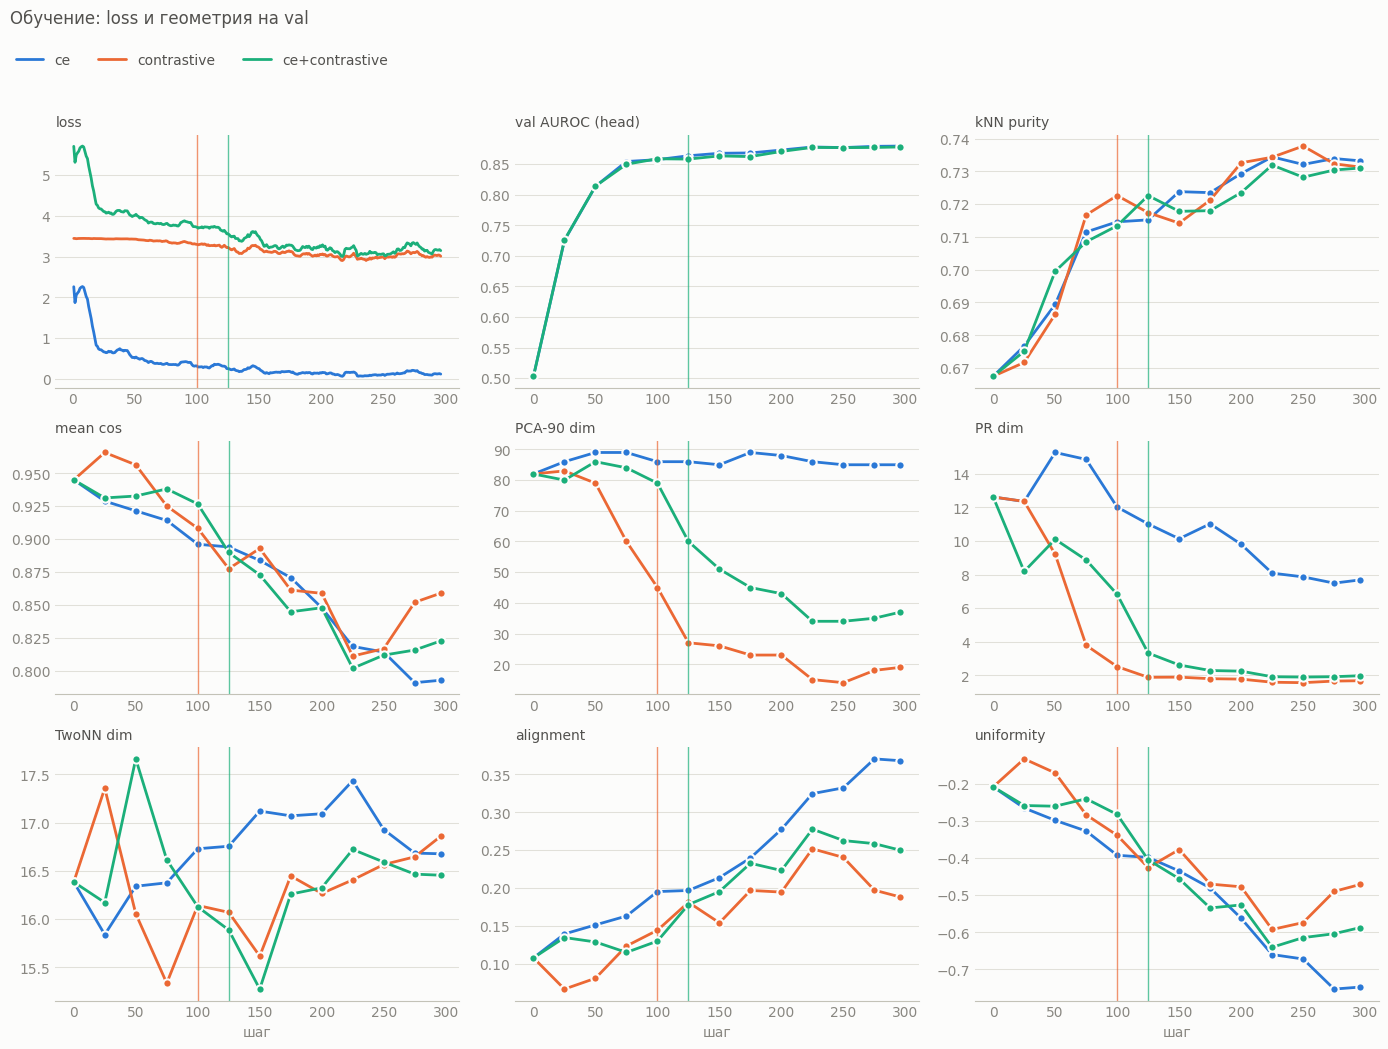

In [19]:
VARIANT_COLORS = {"ce": "#2a78d6", "contrastive": "#eb6834", "ce+contrastive": "#1baf7a"}
SURFACE = "#fcfcfb"
GRIDLINE = "#e1e0d9"
BASELINE = "#c3c2b7"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"

CURVE_PANELS = ("loss", "val AUROC (head)", "kNN purity", "mean cos", "PCA-90 dim", "PR dim",
                "TwoNN dim", "alignment", "uniformity")


def plot_training_curves(history: pd.DataFrame, step_log: pd.DataFrame, collapses: dict):
    figure, axes = plt.subplots(3, 3, figsize=(14, 10.5), squeeze=False, facecolor=SURFACE)

    for axis, panel in zip(axes.flat, CURVE_PANELS):
        for variant_name, color in VARIANT_COLORS.items():
            if panel == "loss":
                steps = step_log[step_log["variant"] == variant_name]
                axis.plot(steps["step"], steps["loss"].rolling(10, min_periods=1).mean(),
                          color=color, linewidth=2, solid_capstyle="round", label=variant_name)
            else:
                rows = history[history["variant"] == variant_name]
                if rows[panel].isna().all():
                    continue
                axis.plot(rows["step"], rows[panel], color=color, linewidth=2, solid_capstyle="round",
                          solid_joinstyle="round", marker="o", markersize=6,
                          markeredgecolor=SURFACE, markeredgewidth=1.5, label=variant_name)
            if collapses.get(variant_name):
                axis.axvline(collapses[variant_name]["step"], color=color, linewidth=1, alpha=0.7)

        axis.set_facecolor(SURFACE)
        axis.set_title(panel, fontsize=10, color=INK_SECONDARY, loc="left")
        axis.grid(axis="y", color=GRIDLINE, linewidth=0.75)
        axis.set_axisbelow(True)
        axis.tick_params(colors=INK_MUTED, length=0)
        for side, spine in axis.spines.items():
            spine.set_visible(side == "bottom")
            spine.set_color(BASELINE)
    for axis in axes[-1]:
        axis.set_xlabel("шаг", color=INK_MUTED)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    figure.suptitle("Обучение: loss и геометрия на val", x=0.01, y=0.995, ha="left", color=INK_SECONDARY)
    figure.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.005, 0.965), ncols=len(labels),
                  frameon=False, labelcolor=INK_SECONDARY)
    figure.tight_layout(rect=(0, 0, 1, 0.94))
    plt.close(figure)
    return figure


TRAINING_FIGURE = plot_training_curves(HISTORY, STEP_LOG, COLLAPSES)
TRAINING_FIGURE.savefig(RESULTS_DIR / "training_curves.png", dpi=150, facecolor=SURFACE)
display(TRAINING_FIGURE)

# Результаты

## Классификация: hold-out против OOD (LODO)

Скоры:

* `head` — лог-отношение шансов головы (только варианты с CE);
* `probe` — логистическая регрессия на эмбеддингах train текущей модели (StandardScaler + L2, `C = PROBE_C`).
  Probe есть у всех, поэтому варианты, включая `contrastive` и `frozen`, сравнимы между собой по одному
  и тому же классификатору.

Probe сохраняется рядом с финальной моделью как `probe.joblib`.

In [20]:
import joblib

SCORERS = {"frozen": ("probe",), "ce": ("head", "probe"), "contrastive": ("probe",), "ce+contrastive": ("head", "probe")}


def fit_probe(outputs: dict[str, dict[str, torch.Tensor]]):
    return make_pipeline(StandardScaler(), LogisticRegression(C=PROBE_C, max_iter=5000)).fit(
        outputs["train"]["embeddings"].numpy(), TRAIN["label"].to_numpy()
    )


def get_scores(model_name: str, scorer: str, dataset: str) -> np.ndarray:
    outputs = EVAL_OUTPUTS[model_name][dataset]
    if scorer == "head":
        return harm_score(outputs["logits"])
    return PROBES[model_name].decision_function(outputs["embeddings"].numpy())


PROBES = {model_name: fit_probe(outputs) for model_name, outputs in EVAL_OUTPUTS.items()}
for variant_name in VARIANTS:
    if variant_name in PROBES:
        joblib.dump(PROBES[variant_name], CHECKPOINT_DIR / variant_name / "final" / "probe.joblib")

classification_rows = {}
for model_name, scorers in SCORERS.items():
    if model_name not in EVAL_OUTPUTS:
        continue
    for scorer in scorers:
        thresholds = select_thresholds(get_scores(model_name, scorer, "val"), VAL["label"].to_numpy())
        for set_name, (dataset, mask) in CLASSIFICATION_SETS.items():
            classification_rows[(model_name, scorer, set_name)] = classification_metrics(
                get_scores(model_name, scorer, dataset)[mask],
                EVAL_FRAMES[dataset]["label"].to_numpy()[mask],
                thresholds,
            )

CLASSIFICATION = pd.DataFrame.from_dict(classification_rows, orient="index")
CLASSIFICATION.index = pd.MultiIndex.from_tuples(CLASSIFICATION.index, names=["model", "scorer", "dataset"])
CLASSIFICATION.to_csv(RESULTS_DIR / "classification.csv")

MAIN_COLUMNS = ["AUROC", "FPR", "FNR", "TPR@FPR=1%", "FPR @ val 1%", "TPR @ val 1%"]
for set_name in CLASSIFICATION_SETS:
    display(style_table(
        CLASSIFICATION.xs(set_name, level="dataset")[MAIN_COLUMNS],
        f"{set_name} · пороги выбраны на val (AEGIS validation)",
    ))

### Интервалы и разрыв ID → OOD

95% бутстрэп-интервалы для AUROC и TPR@FPR=1% и разница hold-out − ToxicChat. Если интервалы двух
вариантов пересекаются, разница между ними на этом объёме данных не доказана.

In [21]:
def with_interval(row: pd.Series, metric: str) -> str:
    return f"{row[metric]:.3f} [{row[f'{metric} low']:.3f}, {row[f'{metric} high']:.3f}]"


INTERVALS = pd.DataFrame({
    (set_name, metric): CLASSIFICATION.xs(set_name, level="dataset").apply(with_interval, axis=1, metric=metric)
    for set_name in CLASSIFICATION_SETS
    for metric in ("AUROC", "TPR@FPR=1%")
})
display(INTERVALS)

LODO_GAP = pd.DataFrame({
    f"{metric} gap": (
        CLASSIFICATION.xs("hold-out", level="dataset")[metric]
        - CLASSIFICATION.xs("ToxicChat", level="dataset")[metric]
    )
    for metric in ("AUROC", "TPR@FPR=1%", "FNR")
})
LODO_GAP["FPR shift @ val 1%"] = CLASSIFICATION.xs("ToxicChat", level="dataset")["FPR @ val 1%"] - TARGET_FPR
LODO_GAP.to_csv(RESULTS_DIR / "classification_lodo_gap.csv")
display(style_table(LODO_GAP, "Разрыв hold-out − ToxicChat (FPR shift — насколько FPR на OOD ушёл от 1%)"))

hold-out                        \
                                      AUROC            TPR@FPR=1%   
model          scorer                                               
frozen         probe   0.773 [0.753, 0.793]  0.082 [0.053, 0.134]   
ce             head    0.861 [0.842, 0.876]  0.182 [0.081, 0.219]   
               probe   0.833 [0.813, 0.851]  0.132 [0.082, 0.177]   
contrastive    probe   0.828 [0.808, 0.847]  0.091 [0.034, 0.160]   
ce+contrastive head    0.860 [0.841, 0.875]  0.177 [0.116, 0.265]   
               probe   0.824 [0.804, 0.843]  0.132 [0.032, 0.173]   

                                  ToxicChat                        \
                                      AUROC            TPR@FPR=1%   
model          scorer                                               
frozen         probe   0.695 [0.670, 0.719]  0.014 [0.003, 0.034]   
ce             head    0.788 [0.762, 0.811]  0.130 [0.054, 0.172]   
               probe   0.758 [0.730, 0.784]  0.113 [0.071, 0.161]   
contrastive    probe   0.756 [0.728, 0.783]  0.037 [0.014, 0.090]   
ce+contrastive head    0.773 [0.746, 0.799]  0.093 [0.054, 0.155]   
               probe   0.776 [0.747, 0.802]  0.133 [0.065, 0.167]   

                      ToxicChat · jailbreaks                        
                                       AUROC            TPR@FPR=1%  
model          scorer                                               
frozen         probe    0.629 [0.590, 0.665]  0.000 [0.000, 0.000]  
ce             head     0.663 [0.615, 0.709]  0.000 [0.000, 0.000]  
               probe    0.723 [0.684, 0.758]  0.011 [0.000, 0.034]  
contrastive    probe    0.740 [0.695, 0.784]  0.022 [0.000, 0.101]  
ce+contrastive head     0.641 [0.584, 0.694]  0.000 [0.000, 0.034]  
               probe    0.708 [0.664, 0.745]  0.067 [0.011, 0.112]

## Геометрия до и после

Одни и те же сбалансированные подвыборки для всех моделей. Вторая таблица — разница с frozen: рост
`kNN purity` и падение `alignment` — классы плотнее и чище; рост `mean cos`, падение размерностей и
рост `uniformity` — пространство схлопывается.

In [22]:
GEOMETRY_SETS = ("val", "hold-out", "ToxicChat")

GEOMETRY = pd.DataFrame.from_dict(
    {
        (dataset, model_name): geometry_metrics(
            EVAL_OUTPUTS[model_name][dataset]["embeddings"][GEOMETRY_INDEX[dataset]],
            EVAL_FRAMES[dataset]["label"].to_numpy()[GEOMETRY_INDEX[dataset]],
        )
        for dataset in GEOMETRY_SETS
        for model_name in EVAL_OUTPUTS
    },
    orient="index",
)
GEOMETRY.index = pd.MultiIndex.from_tuples(GEOMETRY.index, names=["dataset", "model"])
GEOMETRY.to_csv(RESULTS_DIR / "geometry_before_after.csv")

GEOMETRY_DELTA = GEOMETRY - GEOMETRY.xs("frozen", level="model").reindex(GEOMETRY.index, level="dataset")

for dataset in GEOMETRY_SETS:
    display(style_table(GEOMETRY.xs(dataset, level="dataset"), f"{dataset} · геометрия"))
    display(style_table(GEOMETRY_DELTA.xs(dataset, level="dataset").drop(index="frozen"), f"{dataset} · разница с frozen"))

,mean cos,PCA-90 dim,PR dim,TwoNN dim,kNN purity,alignment,uniformity
model,,,,,,,
frozen,0.9450,82.0000,12.6163,16.3844,0.6673,0.1082,-0.2078
ce,0.7928,85.0000,7.6844,16.6782,0.7332,0.3679,-0.7477
contrastive,0.8589,19.0000,1.6886,16.8611,0.7314,0.1883,-0.4710
ce+contrastive,0.8227,37.0000,1.9859,16.4507,0.7311,0.2500,-0.5872


,mean cos,PCA-90 dim,PR dim,TwoNN dim,kNN purity,alignment,uniformity
model,,,,,,,
ce,-0.1522,3.0000,-4.9319,0.2938,0.0659,0.2597,-0.5399
contrastive,-0.0861,-63.0000,-10.9277,0.4768,0.0641,0.0801,-0.2632
ce+contrastive,-0.1223,-45.0000,-10.6304,0.0663,0.0638,0.1418,-0.3795


,mean cos,PCA-90 dim,PR dim,TwoNN dim,kNN purity,alignment,uniformity
model,,,,,,,
frozen,0.9455,82.0000,12.7053,18.5755,0.6348,0.1077,-0.2059
ce,0.7944,87.0000,8.7766,18.3593,0.7393,0.3720,-0.7481
contrastive,0.8651,22.0000,1.7821,17.1843,0.7319,0.1887,-0.4542
ce+contrastive,0.8310,42.0000,2.1723,17.3582,0.7229,0.2509,-0.5683


,mean cos,PCA-90 dim,PR dim,TwoNN dim,kNN purity,alignment,uniformity
model,,,,,,,
ce,-0.1512,5.0000,-3.9286,-0.2162,0.1045,0.2643,-0.5422
contrastive,-0.0804,-60.0000,-10.9232,-1.3913,0.0971,0.0810,-0.2483
ce+contrastive,-0.1146,-40.0000,-10.5330,-1.2173,0.0881,0.1432,-0.3624


,mean cos,PCA-90 dim,PR dim,TwoNN dim,kNN purity,alignment,uniformity
model,,,,,,,
frozen,0.9411,82.0000,13.4547,8.6157,0.6919,0.1135,-0.2297
ce,0.7992,92.0000,11.7323,9.8582,0.7633,0.3719,-0.7366
contrastive,0.8799,35.0000,2.1712,10.7470,0.7356,0.1941,-0.4266
ce+contrastive,0.8533,58.0000,2.8938,10.3646,0.7278,0.2509,-0.5211


,mean cos,PCA-90 dim,PR dim,TwoNN dim,kNN purity,alignment,uniformity
model,,,,,,,
ce,-0.1419,10.0000,-1.7224,1.2424,0.0713,0.2584,-0.5069
contrastive,-0.0612,-47.0000,-11.2835,2.1313,0.0436,0.0806,-0.1969
ce+contrastive,-0.0878,-24.0000,-10.5609,1.7489,0.0359,0.1374,-0.2914


# Сравнение с бейзлайнами RQ1

Те же датасеты и выборки, что в `visual_clust.ipynb`:

* **RQ1** — пары benign/harmful из SafeSteer, FORTRESS и JBB (промпты до 15 000 символов);
* **WildGuardMix** — по 400 промптов в каждой ячейке класс × стиль (vanilla / adversarial).

Эмбеддинги — как в RQ1: masked mean pooling, стандартная обрезка токенизатора, матрицы (d, n). К пяти
frozen-бейзлайнам добавлены финальные модели трёх вариантов из `checkpoints/<variant>/final`. Если
бейзлайн не загружается (нет доступа к gated-модели, не установлен `gliner2`), он пропускается с
сообщением. Эмбеддинги кэшируются в `results/embeddings_rq1_datasets.pt`; дообученные модели
пересчитываются при каждом запуске.

In [23]:
RQ1_MAX_PROMPT_CHARS = 15_000
RQ1_SAMPLE_PER_CELL = 400
RQ1_STYLE_NAMES = ("vanilla", "adversarial")
RQ1_CACHE_PATH = RESULTS_DIR / "embeddings_rq1_datasets.pt"
RQ1_BATCH_SIZES = {"Prompt-Guard-2-86M": 2}
RQ1_DEFAULT_BATCH_SIZE = 8


def is_out_of_memory(error: Exception) -> bool:
    return isinstance(error, torch.OutOfMemoryError) or "out of memory" in str(error).lower()


class MeanPoolingEmbedder:
    """Masked mean pooling по последнему слою энкодера. Возвращает матрицу (d, n)."""

    model_name: str

    def __init__(self, batch_size: int = RQ1_DEFAULT_BATCH_SIZE) -> None:
        self.batch_size = batch_size
        self.model, self.tokenizer = self._load()
        self.model = self.model.to(DEVICE).eval()

    def _load(self):
        return AutoModel.from_pretrained(self.model_name), AutoTokenizer.from_pretrained(self.model_name)

    def _hidden_state(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model(**batch).last_hidden_state

    def _prepare_texts(self, texts: list[str]) -> list[str]:
        return texts

    def embed(self, texts) -> torch.Tensor:
        texts = self._prepare_texts(list(texts))
        vectors = []
        batch_size = self.batch_size
        start = 0

        # при нехватке памяти тот же кусок пересчитывается меньшим батчем
        while start < len(texts):
            try:
                with torch.inference_mode():
                    batch = self.tokenizer(
                        texts[start:start + batch_size], padding="longest", truncation=True, return_tensors="pt",
                    )
                    batch = {name: tensor.to(DEVICE) for name, tensor in batch.items()}
                    hidden_state = self._hidden_state(batch)
                    mask = batch["attention_mask"].unsqueeze(-1).to(hidden_state.dtype)
                    vectors.append(((hidden_state * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)).float().cpu())
            except (torch.OutOfMemoryError, RuntimeError) as error:
                if not is_out_of_memory(error) or batch_size == 1:
                    raise
                free_memory()
                batch_size //= 2
                print(f"{self.model_name}: не хватило памяти, batch_size -> {batch_size}")
                continue
            start += batch_size

        return torch.cat(vectors, dim=0).T.contiguous()

    def __call__(self, texts) -> torch.Tensor:
        return self.embed(texts)


class EttinEncoder68M(MeanPoolingEmbedder):
    model_name = "jhu-clsp/ettin-encoder-68m"


class MmBertSmall(MeanPoolingEmbedder):
    model_name = "jhu-clsp/mmBERT-small"


class E5SmallV2(MeanPoolingEmbedder):
    model_name = "intfloat/e5-small-v2"

    def _prepare_texts(self, texts: list[str]) -> list[str]:
        return [f"query: {text}" for text in texts]


class PromptGuard2_86M(MeanPoolingEmbedder):
    """Prompt Guard 2 — mDeBERTa с бинарной головой; берётся представление бэкбона."""

    model_name = "meta-llama/Llama-Prompt-Guard-2-86M"

    def _load(self):
        return (
            AutoModelForSequenceClassification.from_pretrained(self.model_name),
            AutoTokenizer.from_pretrained(self.model_name),
        )

    def _hidden_state(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model.deberta(**batch).last_hidden_state


class GlinerGuardUniEncoder(MeanPoolingEmbedder):
    """GLiNER2 — nn.Module: бэкбон в .encoder, токенизатор в .processor.tokenizer."""

    model_name = "hivetrace/gliner-guard-uniencoder"

    def _load(self):
        from gliner2 import GLiNER2

        model = GLiNER2.from_pretrained(self.model_name)
        return model, model.processor.tokenizer

    def _hidden_state(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        return self.model.encoder(**batch).last_hidden_state


FINE_TUNED_TYPES = {
    f"mmBERT-small · {variant_name}": type(
        f"FineTuned{index}", (MeanPoolingEmbedder,), {"model_name": str(CHECKPOINT_DIR / variant_name / "final")}
    )
    for index, variant_name in enumerate(VARIANTS)
    if (CHECKPOINT_DIR / variant_name / "final").exists()
}

EMBEDDER_TYPES = {
    "ettin-encoder-68m": EttinEncoder68M,
    "mmBERT-small": MmBertSmall,
    "e5-small-v2": E5SmallV2,
    "Prompt-Guard-2-86M": PromptGuard2_86M,
    "gliner-guard-uniencoder": GlinerGuardUniEncoder,
    **FINE_TUNED_TYPES,
}

## Датасеты RQ1

In [24]:
def read_hf(repo: str, filename: str) -> pl.DataFrame:
    path = hf_hub_download(repo_id=repo, filename=filename, repo_type="dataset", token=os.environ["HF_TOKEN"])
    return pl.read_csv(path) if filename.endswith(".csv") else pl.read_parquet(path)


jbb_harmful = read_hf("JailbreakBench/JBB-Behaviors", "data/harmful-behaviors.csv")
jbb_benign = read_hf("JailbreakBench/JBB-Behaviors", "data/benign-behaviors.csv")
fortress = read_hf("ScaleAI/fortress_public", "data/train-00000-of-00001.parquet")
safesteer = pl.concat([read_hf("NASK-PIB/SafeSteerDataset", f"{split}.parquet") for split in ("test", "train")])

safesteer_pairs = safesteer.select(
    pl.col("unsafe_prompt").alias("harmful_prompt"),
    pl.col("safe_prompt").alias("benign_prompt"),
).with_columns(pl.lit("SafeSteer").alias("source"))

fortress_pairs = fortress.select(
    pl.col("adversarial_prompt").alias("harmful_prompt"),
    pl.col("benign_prompt"),
).with_columns(pl.lit("FORTRESS").alias("source"))

jbb_pairs = (
    jbb_harmful
    .select("Index", pl.col("Goal").alias("harmful_prompt"))
    .join(jbb_benign.select("Index", pl.col("Goal").alias("benign_prompt")), on="Index", how="inner", validate="1:1")
    .sort("Index")
    .select("harmful_prompt", "benign_prompt")
    .with_columns(pl.lit("JBB").alias("source"))
)

rq1_pairs = (
    pl.concat([safesteer_pairs, fortress_pairs, jbb_pairs])
    .filter(
        (pl.col("harmful_prompt").str.len_chars() <= RQ1_MAX_PROMPT_CHARS)
        & (pl.col("benign_prompt").str.len_chars() <= RQ1_MAX_PROMPT_CHARS)
    )
    .with_row_index("pair_id")
    .sample(fraction=1.0, shuffle=True, seed=SEED)
)

RQ1_BENIGN = rq1_pairs.select(pl.col("benign_prompt").alias("prompt"), "source", "pair_id")
RQ1_HARMFUL = rq1_pairs.select(pl.col("harmful_prompt").alias("prompt"), "source", "pair_id")

# Порядок меток совпадает с порядком эмбеддингов: сначала весь benign, затем весь harmful.
RQ1_LABELS = np.array(["benign"] * len(RQ1_BENIGN) + ["harmful"] * len(RQ1_HARMFUL))
RQ1_SOURCES = np.concatenate([rq1_pairs["source"].to_numpy()] * 2)

wildguard = read_hf("allenai/wildguardmix", "train/wildguard_train.parquet")
wildguard_prompts = (
    wildguard
    .filter(pl.col("prompt_harm_label").is_not_null())
    .unique(subset=["prompt"], keep="first", maintain_order=True)
    .select("prompt", "prompt_harm_label", "adversarial")
    .with_columns(pl.when(pl.col("adversarial")).then(pl.lit("adversarial")).otherwise(pl.lit("vanilla")).alias("style"))
)


def sample_wildguard(harm_label: str) -> pl.DataFrame:
    parts = []
    for style_name in RQ1_STYLE_NAMES:
        cell = wildguard_prompts.filter((pl.col("prompt_harm_label") == harm_label) & (pl.col("style") == style_name))
        parts.append(cell.sample(n=min(RQ1_SAMPLE_PER_CELL, len(cell)), seed=SEED, shuffle=True))
    return pl.concat(parts).select("prompt", "style")


WG_BENIGN = sample_wildguard("unharmful")
WG_HARMFUL = sample_wildguard("harmful")
WG_LABELS = np.array(["benign"] * len(WG_BENIGN) + ["harmful"] * len(WG_HARMFUL))
WG_STYLES = np.concatenate([WG_BENIGN["style"].to_numpy(), WG_HARMFUL["style"].to_numpy()])

RQ1_DATASETS = {
    "RQ1": (RQ1_BENIGN, RQ1_HARMFUL),
    "WildGuardMix": (WG_BENIGN, WG_HARMFUL),
}
display(rq1_pairs.group_by("source").agg(pl.len().alias("pairs")).sort("pairs", descending=True).to_pandas())
print("WildGuardMix:", len(WG_BENIGN), len(WG_HARMFUL))

,source,pairs
0,SafeSteer,2300
1,FORTRESS,498
2,JBB,100


WildGuardMix: 800 800


In [25]:
def get_rq1_embeddings() -> dict[str, dict[str, dict[str, torch.Tensor]]]:
    try:
        cache = torch.load(RQ1_CACHE_PATH, weights_only=True)
    except FileNotFoundError:
        cache = {}

    for dataset_name, (benign_frame, _) in RQ1_DATASETS.items():
        groups = cache.setdefault(dataset_name, {})
        for model_name in list(groups):
            if model_name in FINE_TUNED_TYPES or groups[model_name]["benign"].shape[1] != len(benign_frame):
                del groups[model_name]

    for model_name, embedder_type in EMBEDDER_TYPES.items():
        pending = [dataset_name for dataset_name in RQ1_DATASETS if model_name not in cache[dataset_name]]
        if not pending:
            print(f"{model_name}: из кэша")
            continue

        try:
            embedder = embedder_type(batch_size=RQ1_BATCH_SIZES.get(model_name, RQ1_DEFAULT_BATCH_SIZE))
        except Exception as error:  # нет доступа к gated-модели, не установлен gliner2 и т. п.
            print(f"{model_name}: пропускаем — {type(error).__name__}: {error}")
            continue

        print(f"{model_name}: считаем {pending}")
        for dataset_name in pending:
            benign_frame, harmful_frame = RQ1_DATASETS[dataset_name]
            matrices = {"benign": embedder(benign_frame["prompt"]), "harmful": embedder(harmful_frame["prompt"])}
            matrices["all"] = torch.cat([matrices["benign"], matrices["harmful"]], dim=1)
            cache[dataset_name][model_name] = matrices
            torch.save(cache, RQ1_CACHE_PATH)

        del embedder
        free_memory()

    return {
        dataset_name: {model_name: cache[dataset_name][model_name] for model_name in EMBEDDER_TYPES if model_name in cache[dataset_name]}
        for dataset_name in RQ1_DATASETS
    }


RQ1_EMBEDDINGS = get_rq1_embeddings()
for dataset_name, matrices in RQ1_EMBEDDINGS.items():
    print(dataset_name, {name: tuple(groups["all"].shape) for name, groups in matrices.items()})

ettin-encoder-68m: из кэша
mmBERT-small: из кэша
e5-small-v2: из кэша
Prompt-Guard-2-86M: из кэша
gliner-guard-uniencoder: из кэша
mmBERT-small · ce: считаем ['RQ1', 'WildGuardMix']
mmBERT-small · contrastive: считаем ['RQ1', 'WildGuardMix']
mmBERT-small · ce+contrastive: считаем ['RQ1', 'WildGuardMix']
RQ1 {'ettin-encoder-68m': (512, 5796), 'mmBERT-small': (384, 5796), 'e5-small-v2': (384, 5796), 'Prompt-Guard-2-86M': (768, 5796), 'gliner-guard-uniencoder': (384, 5796), 'mmBERT-small · ce': (384, 5796), 'mmBERT-small · contrastive': (384, 5796), 'mmBERT-small · ce+contrastive': (384, 5796)}
WildGuardMix {'ettin-encoder-68m': (512, 1600), 'mmBERT-small': (384, 1600), 'e5-small-v2': (384, 1600), 'Prompt-Guard-2-86M': (768, 1600), 'gliner-guard-uniencoder': (384, 1600), 'mmBERT-small · ce': (384, 1600), 'mmBERT-small · contrastive': (384, 1600), 'mmBERT-small · ce+contrastive': (384, 1600)}


## Метрики расстояния из RQ1

Функции из `RQ1.ipynb` без изменений (с поправкой на нечётный размер выборки из `CodeDomain.ipynb`):

* `within_benign`, `within_harmful` — среднее расстояние между случайными текстами одного класса;
* `within_pair` (RQ1) — между benign и harmful одной пары; в WildGuardMix пар нет, поэтому
  `cross_class` — между случайными benign и harmful;
* отношение расстояния между центрами классов к среднему внутриклассовому расстоянию (`cosine`, `L2`).

L2 зависит от нормы эмбеддингов конкретной модели, поэтому между моделями сравнимы косинусные метрики и
отношения. Считается по всему датасету и отдельно по источнику (RQ1) или стилю (WildGuardMix).

In [26]:
def describe(x: torch.Tensor, short: bool = False) -> dict[str, float]:
    x = x.detach().to(device=DEVICE, dtype=torch.float32)
    stat = {"mean": x.mean().item(), "std": x.std(unbiased=True).item()}
    if short:
        return stat
    stat["25%"] = torch.quantile(x, 0.25).item()
    stat["50%"] = torch.quantile(x, 0.50).item()
    stat["75%"] = torch.quantile(x, 0.75).item()
    return stat


def cos_similarity(x: torch.Tensor, y: torch.Tensor, dim: int = 0) -> torch.Tensor:
    x_norm = F.normalize(x, p=2, dim=dim)
    y_norm = F.normalize(y, p=2, dim=dim)
    return (x_norm * y_norm).sum(dim=dim)


def describe_mean_cos_distance(x: torch.Tensor, y: torch.Tensor, same_sample: bool = False, n: int = 100) -> dict[str, float]:
    runs = []
    for _ in range(n):
        rand_perm = torch.randperm(x.shape[1], device=x.device)
        sample_size = rand_perm.shape[0]
        sample_x = x[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)
        if same_sample:
            # при нечётном числе примеров вторая половина на один длиннее — обрезаем до размера первой
            sample_y = y[:, rand_perm[int(sample_size // 2):2 * int(sample_size // 2)]].to(device=DEVICE)
        else:
            sample_y = y[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)
        runs.append(1 - cos_similarity(sample_x, sample_y).mean())
    return describe(torch.tensor(runs), short=True)


def describe_mean_l2_distance(x: torch.Tensor, y: torch.Tensor, same_sample: bool = False, n: int = 100) -> dict[str, float]:
    runs = []
    for _ in range(n):
        rand_perm = torch.randperm(x.shape[1], device=x.device)
        sample_size = rand_perm.shape[0]
        sample_x = x[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)
        if same_sample:
            sample_y = y[:, rand_perm[int(sample_size // 2):2 * int(sample_size // 2)]].to(device=DEVICE)
        else:
            sample_y = y[:, rand_perm[:int(sample_size // 2)]].to(device=DEVICE)
        runs.append((sample_x - sample_y).norm(p=2, dim=0).mean())
    return describe(torch.tensor(runs), short=True)


def calc_distance_ratio(x: torch.Tensor, y: torch.Tensor) -> dict[str, float]:
    x_center = x.mean(dim=1, keepdim=True)
    x_within_class_cos = describe_mean_cos_distance(x, x, same_sample=True)["mean"]
    x_within_class_l2 = describe_mean_l2_distance(x, x, same_sample=True)["mean"]

    y_center = y.mean(dim=1, keepdim=True)
    y_within_class_cos = describe_mean_cos_distance(y, y, same_sample=True)["mean"]
    y_within_class_l2 = describe_mean_l2_distance(y, y, same_sample=True)["mean"]

    return {
        "cosine": (2 * (1 - cos_similarity(x_center, y_center)) / (x_within_class_cos + y_within_class_cos)).item(),
        "L2": (2 * (x_center - y_center).norm(p=2) / (x_within_class_l2 + y_within_class_l2)).item(),
    }


def describe_mean_distance(x: torch.Tensor, y: torch.Tensor, same_sample: bool = False, n: int = 100) -> dict[str, float]:
    cos = describe_mean_cos_distance(x, y, same_sample, n)
    l2 = describe_mean_l2_distance(x, y, same_sample, n)
    return {
        "cosine (mean)": cos["mean"],
        "cosine (std)": cos["std"],
        "L2 (mean)": l2["mean"],
        "L2 (std)": l2["std"],
    }

In [27]:
rq1_source_by_pair = rq1_pairs["source"].to_numpy()
DISTANCE_GROUPS = {
    "RQ1": {
        "all": (np.ones(len(RQ1_BENIGN), dtype=bool),) * 2,
        **{source: (rq1_source_by_pair == source,) * 2 for source in ("SafeSteer", "FORTRESS", "JBB")},
    },
    "WildGuardMix": {
        "all": (np.ones(len(WG_BENIGN), dtype=bool), np.ones(len(WG_HARMFUL), dtype=bool)),
        **{
            style: (WG_BENIGN["style"].to_numpy() == style, WG_HARMFUL["style"].to_numpy() == style)
            for style in RQ1_STYLE_NAMES
        },
    },
}
BETWEEN_CLASS_NAME = {"RQ1": "within_pair", "WildGuardMix": "cross_class"}

torch.manual_seed(SEED)
distance_rows, ratio_rows = {}, {}
for dataset_name, groups in DISTANCE_GROUPS.items():
    for group_name, (benign_mask, harmful_mask) in groups.items():
        for model_name, matrices in RQ1_EMBEDDINGS[dataset_name].items():
            benign = matrices["benign"][:, torch.from_numpy(benign_mask)]
            harmful = matrices["harmful"][:, torch.from_numpy(harmful_mask)]
            for kind, arguments in (
                ("within_benign", (benign, benign, True)),
                ("within_harmful", (harmful, harmful, True)),
                (BETWEEN_CLASS_NAME[dataset_name], (benign, harmful)),
            ):
                distance_rows[(dataset_name, group_name, model_name, kind)] = describe_mean_distance(*arguments)
            ratio_rows[(dataset_name, group_name, model_name)] = calc_distance_ratio(benign, harmful)

RQ1_DISTANCES = pd.DataFrame.from_dict(distance_rows, orient="index")
RQ1_DISTANCES.index = pd.MultiIndex.from_tuples(RQ1_DISTANCES.index, names=["dataset", "group", "model", "distance"])
RQ1_RATIOS = pd.DataFrame.from_dict(ratio_rows, orient="index")
RQ1_RATIOS.index = pd.MultiIndex.from_tuples(RQ1_RATIOS.index, names=["dataset", "group", "model"])
RQ1_DISTANCES.to_csv(RESULTS_DIR / "rq1_mean_distances.csv")
RQ1_RATIOS.to_csv(RESULTS_DIR / "rq1_distance_ratios.csv")

for dataset_name in DISTANCE_GROUPS:
    display(style_table(
        RQ1_DISTANCES.xs((dataset_name, "all"), level=("dataset", "group")),
        f"{dataset_name} · Mean distance",
    ))
    display(style_table(
        RQ1_RATIOS.xs(dataset_name, level="dataset")["cosine"].unstack("group"),
        f"{dataset_name} · Distance between class centers / mean within-class distance (cosine)",
    ))
    display(style_table(
        RQ1_RATIOS.xs(dataset_name, level="dataset")["L2"].unstack("group"),
        f"{dataset_name} · Distance between class centers / mean within-class distance (L2)",
    ))

group,all,SafeSteer,FORTRESS,JBB
model,,,,
Prompt-Guard-2-86M,0.0681,0.0636,0.3735,0.3885
e5-small-v2,0.0499,0.0752,0.0573,0.0299
ettin-encoder-68m,0.0422,0.0582,0.1750,0.0274
gliner-guard-uniencoder,0.0516,0.0688,0.1300,0.0320
mmBERT-small,0.0452,0.0593,0.1076,0.0297
mmBERT-small · ce,0.2045,0.3349,0.0746,0.1653
mmBERT-small · ce+contrastive,0.4430,0.8532,0.1131,0.1803
mmBERT-small · contrastive,0.4259,0.7852,0.0406,0.1512


group,all,SafeSteer,FORTRESS,JBB
model,,,,
Prompt-Guard-2-86M,0.2983,0.2589,0.6648,0.6099
e5-small-v2,0.1974,0.2444,0.2159,0.1557
ettin-encoder-68m,0.2399,0.3192,0.4344,0.1866
gliner-guard-uniencoder,0.2207,0.2598,0.4494,0.1924
mmBERT-small,0.2106,0.2483,0.3501,0.1930
mmBERT-small · ce,0.4687,0.5979,0.2582,0.3574
mmBERT-small · ce+contrastive,0.6544,0.9047,0.3349,0.4173
mmBERT-small · contrastive,0.7651,1.0516,0.2041,0.4887


group,all,vanilla,adversarial
model,,,
Prompt-Guard-2-86M,0.1470,0.3362,0.1829
e5-small-v2,0.0282,0.0648,0.0170
ettin-encoder-68m,0.0273,0.0834,0.0211
gliner-guard-uniencoder,0.0552,0.1492,0.0329
mmBERT-small,0.0505,0.1525,0.0220
mmBERT-small · ce,0.1361,0.3317,0.0396
mmBERT-small · ce+contrastive,0.3581,0.8303,0.0822
mmBERT-small · contrastive,0.3535,0.7497,0.1157


group,all,vanilla,adversarial
model,,,
Prompt-Guard-2-86M,0.3631,0.6065,0.4160
e5-small-v2,0.1502,0.2260,0.1216
ettin-encoder-68m,0.2328,0.4165,0.1570
gliner-guard-uniencoder,0.2334,0.3735,0.1790
mmBERT-small,0.2316,0.4008,0.1684
mmBERT-small · ce,0.3739,0.5493,0.2181
mmBERT-small · ce+contrastive,0.5939,0.8852,0.3054
mmBERT-small · contrastive,0.6647,1.0035,0.3663


## Геометрия на датасетах RQ1

Те же метрики, что до/после обучения, на сбалансированной подвыборке по `GEOMETRY_PER_CLASS` на класс.

In [28]:
RQ1_CLASS_LABELS = {"RQ1": RQ1_LABELS, "WildGuardMix": WG_LABELS}

rq1_geometry_rows = {}
for dataset_name, matrices_by_model in RQ1_EMBEDDINGS.items():
    labels = (RQ1_CLASS_LABELS[dataset_name] == "harmful").astype(int)
    index = balanced_subsample(labels)
    for model_name, matrices in matrices_by_model.items():
        rq1_geometry_rows[(dataset_name, model_name)] = geometry_metrics(matrices["all"].T[index], labels[index])

RQ1_GEOMETRY = pd.DataFrame.from_dict(rq1_geometry_rows, orient="index")
RQ1_GEOMETRY.index = pd.MultiIndex.from_tuples(RQ1_GEOMETRY.index, names=["dataset", "model"])
RQ1_GEOMETRY.to_csv(RESULTS_DIR / "rq1_geometry.csv")
for dataset_name in RQ1_EMBEDDINGS:
    display(style_table(RQ1_GEOMETRY.xs(dataset_name, level="dataset"), f"{dataset_name} · геометрия"))

,mean cos,PCA-90 dim,PR dim,TwoNN dim,kNN purity,alignment,uniformity
model,,,,,,,
ettin-encoder-68m,0.9650,116.0000,18.0999,18.0159,0.7290,0.0685,-0.1369
mmBERT-small,0.9618,92.0000,33.7162,17.1573,0.7286,0.0747,-0.1512
e5-small-v2,0.7706,177.0000,67.4565,15.5018,0.7506,0.4497,-0.9079
Prompt-Guard-2-86M,0.9376,17.0000,3.9727,18.5369,0.6413,0.1214,-0.1872
gliner-guard-uniencoder,0.9529,96.0000,28.8113,18.1940,0.7518,0.0918,-0.1837
mmBERT-small · ce,0.8333,88.0000,10.1351,19.2275,0.7928,0.3067,-0.6278
mmBERT-small · contrastive,0.9032,29.0000,2.1733,16.4342,0.7505,0.1583,-0.3368
mmBERT-small · ce+contrastive,0.8736,57.0000,2.7660,20.1773,0.7645,0.2145,-0.4488


,mean cos,PCA-90 dim,PR dim,TwoNN dim,kNN purity,alignment,uniformity
model,,,,,,,
ettin-encoder-68m,0.9523,86.0000,5.3796,22.5431,0.6557,0.0934,-0.1739
mmBERT-small,0.9552,79.0000,8.7929,21.3688,0.6578,0.0873,-0.1717
e5-small-v2,0.7947,209.0000,85.9533,25.6992,0.6725,0.4061,-0.8081
Prompt-Guard-2-86M,0.7429,3.0000,1.7423,14.9719,0.6360,0.4889,-0.6656
gliner-guard-uniencoder,0.9473,81.0000,9.6297,23.2035,0.6701,0.1026,-0.2002
mmBERT-small · ce,0.8355,86.0000,10.1605,23.6690,0.6796,0.3098,-0.5843
mmBERT-small · contrastive,0.9003,28.0000,2.1718,21.9750,0.6826,0.1695,-0.3533
mmBERT-small · ce+contrastive,0.8861,51.0000,2.7850,22.7630,0.6612,0.1974,-0.3997


## t-SNE

Как в `visual_clust.ipynb`: t-SNE на сырых эмбеддингах после L2-нормировки, perplexity 30, `init="pca"`.
Каждая проекция строится один раз и раскрашивается дважды — по классу и по источнику (RQ1) или
стилю (WildGuardMix).

ettin-encoder-68m: готово
mmBERT-small: готово
e5-small-v2: готово
Prompt-Guard-2-86M: готово
gliner-guard-uniencoder: готово
mmBERT-small · ce: готово
mmBERT-small · contrastive: готово
mmBERT-small · ce+contrastive: готово


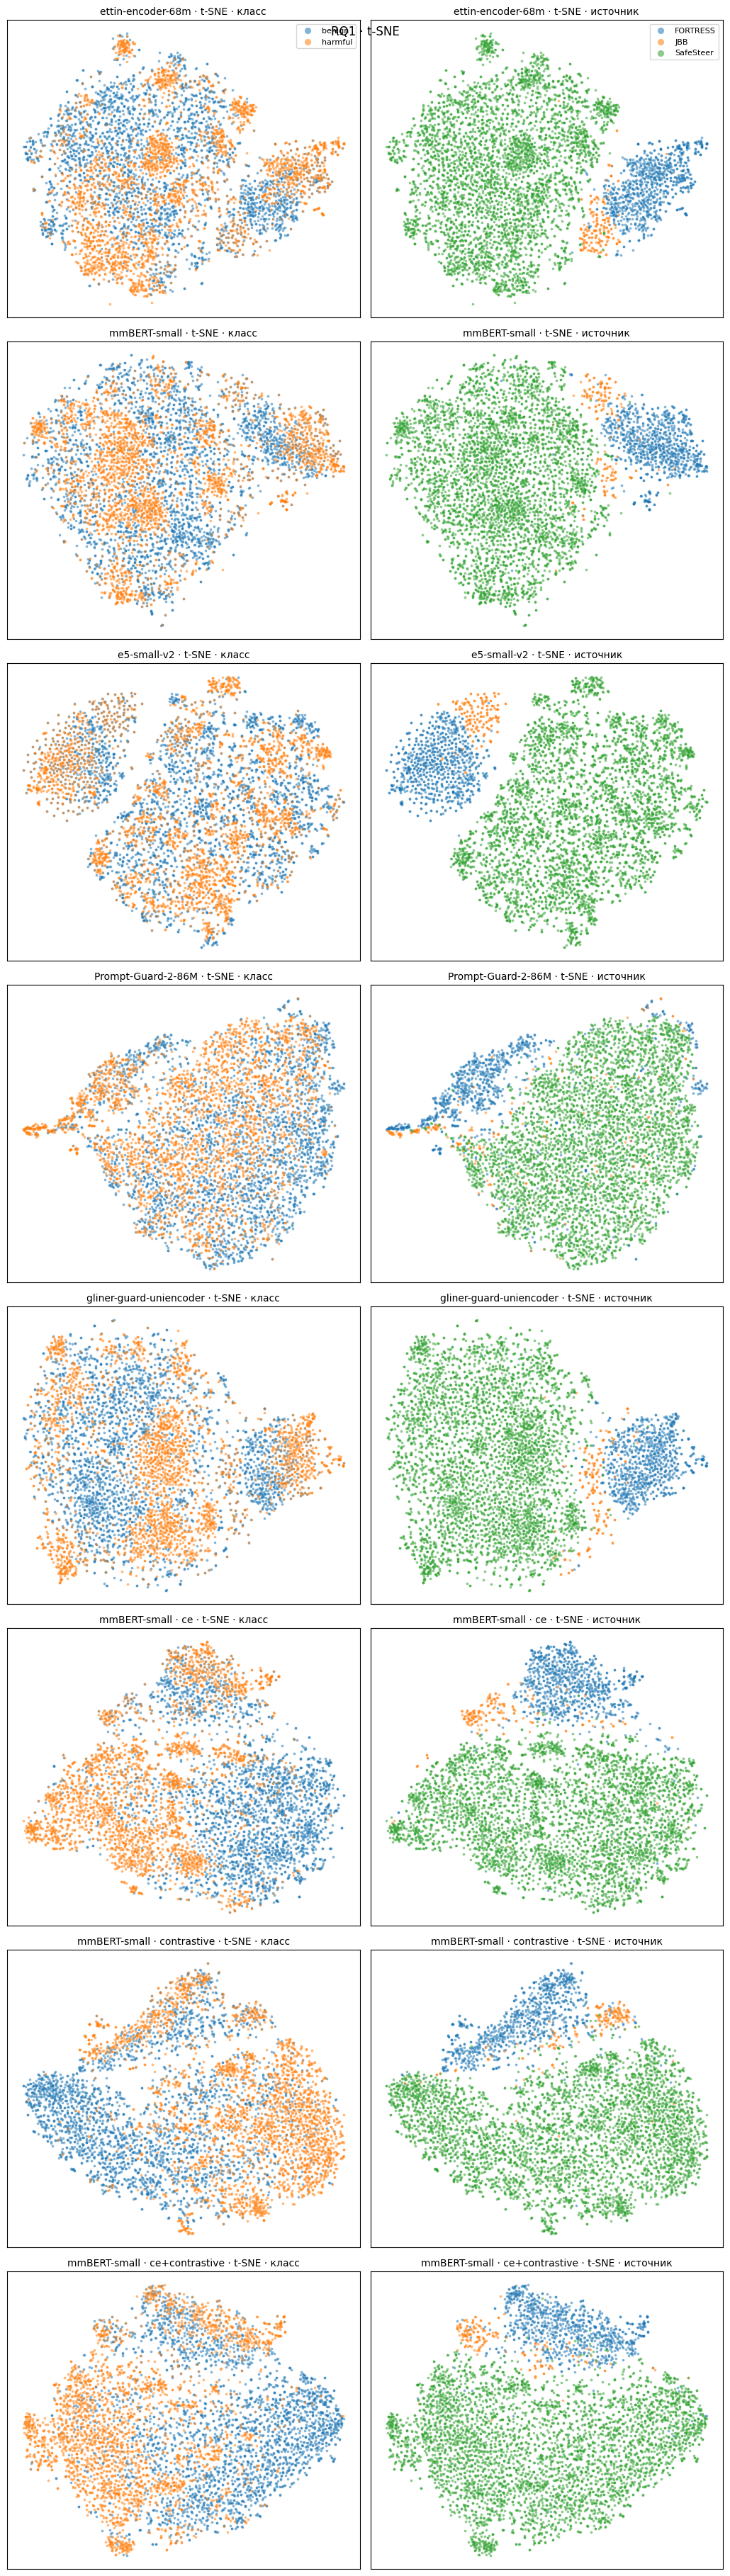

ettin-encoder-68m: готово
mmBERT-small: готово
e5-small-v2: готово
Prompt-Guard-2-86M: готово
gliner-guard-uniencoder: готово
mmBERT-small · ce: готово
mmBERT-small · contrastive: готово
mmBERT-small · ce+contrastive: готово


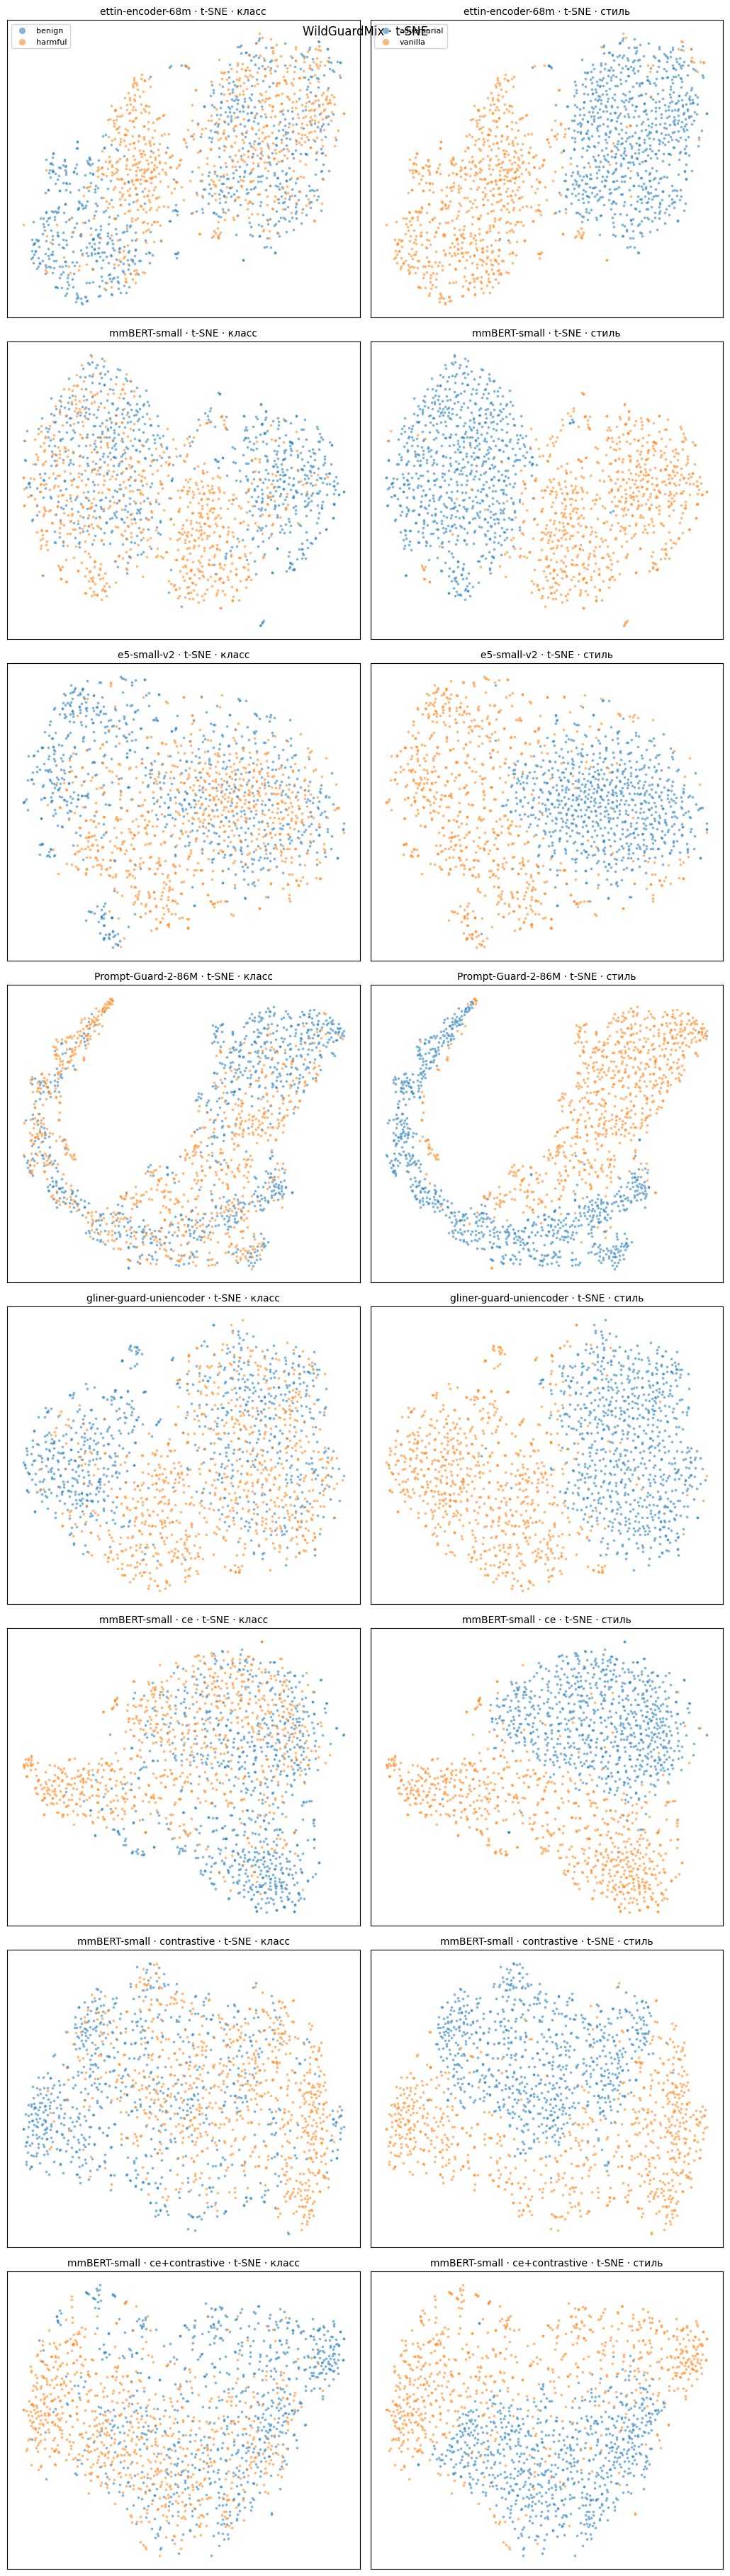

In [29]:
def get_points(embeddings: torch.Tensor) -> np.ndarray:
    """Матрица (n, d) после L2-нормировки."""
    return F.normalize(embeddings, p=2, dim=0).detach().to(device="cpu", dtype=torch.float32).T.numpy()


def get_tsne_projections(embeddings: dict[str, torch.Tensor]) -> dict[str, np.ndarray]:
    projections = {}
    for name, matrix in embeddings.items():
        projections[name] = TSNE(
            n_components=2, perplexity=30.0, init="pca", learning_rate="auto", random_state=SEED,
        ).fit_transform(get_points(matrix))
        print(f"{name}: готово")
    return projections


def plot_projections(projections: dict[str, np.ndarray], colorings: dict[str, np.ndarray], title: str, point_size: float = 7.0):
    """Строки — модели, колонки — раскраски."""
    figure, axes = plt.subplots(
        len(projections), len(colorings),
        figsize=(5.2 * len(colorings), 4.6 * len(projections)),
        squeeze=False,
    )
    palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for row, (model_name, projection) in enumerate(projections.items()):
        for column, (coloring_name, labels) in enumerate(colorings.items()):
            axis = axes[row][column]
            for color_number, value in enumerate(sorted(set(labels.tolist()))):
                mask = labels == value
                axis.scatter(
                    projection[mask, 0], projection[mask, 1],
                    s=point_size, alpha=0.55, linewidths=0,
                    color=palette[color_number % len(palette)], label=str(value),
                )
            axis.set_title(f"{model_name} · t-SNE · {coloring_name}", fontsize=10)
            axis.set_xticks([])
            axis.set_yticks([])
            axis.grid(alpha=0.2)
            if row == 0:
                axis.legend(markerscale=2.5, fontsize=8)

    figure.suptitle(title)
    figure.tight_layout()
    plt.close(figure)
    return figure


RQ1_COLORINGS = {
    "RQ1": {"класс": RQ1_LABELS, "источник": RQ1_SOURCES},
    "WildGuardMix": {"класс": WG_LABELS, "стиль": WG_STYLES},
}

TSNE_PROJECTIONS = {}
for dataset_name, matrices_by_model in RQ1_EMBEDDINGS.items():
    TSNE_PROJECTIONS[dataset_name] = get_tsne_projections({name: groups["all"] for name, groups in matrices_by_model.items()})
    tsne_figure = plot_projections(TSNE_PROJECTIONS[dataset_name], RQ1_COLORINGS[dataset_name], f"{dataset_name} · t-SNE")
    tsne_figure.savefig(RESULTS_DIR / f"tsne_{dataset_name}.png", dpi=120)
    display(tsne_figure)

In [30]:
upload_outputs("RQ3: результаты, метрики RQ1 и t-SNE")

выгружено: https://huggingface.co/marusyan132/rq3-mmbert-small


# Что сохранено

* `checkpoints/<variant>/final/` — финальная модель: энкодер и токенизатор (`save_pretrained`),
  `classifier_head.pt`, `probe.joblib`, `rq3_training.json` (конфиг, веса loss, событие поломки геометрии);
* `checkpoints/<variant>/last_healthy_step*/` — последнее состояние до поломки геометрии, если она была;
* `results/` — `classification.csv`, `classification_lodo_gap.csv`, `geometry_before_after.csv`,
  `geometry_collapse.json`, `training_geometry_history.csv`, `training_steps.csv`, `training_curves.png`,
  `rq1_mean_distances.csv`, `rq1_distance_ratios.csv`, `rq1_geometry.csv`, `tsne_*.png` и кэши
  эмбеддингов `*.pt` (в `.gitignore`).

Если задан `HF_CHECKPOINT_REPO`, `checkpoints/` и `results/` (без `*.pt`) лежат в приватном репозитории
Hugging Face. На своей машине из корня проекта они скачиваются в те же папки (нужен
`huggingface_hub` с CLI `hf` и токен с доступом к репозиторию):

```bash
hf download <HF_CHECKPOINT_REPO> --include "checkpoints/*" --include "results/*" --local-dir rq3_training
```

Загрузка финальной модели:

```python
path = "rq3_training/checkpoints/ce+contrastive/final"
encoder = AutoModel.from_pretrained(path)
tokenizer = AutoTokenizer.from_pretrained(path)
head = nn.Linear(encoder.config.hidden_size, 2)
head.load_state_dict(torch.load(f"{path}/classifier_head.pt"))
```

Эмбеддинг — masked mean pooling по `last_hidden_state`. Обучение шло с обрезкой «голова + хвост» до
`MAX_LENGTH` токенов (функция `tokenize` выше).